# An analysis of Heart Disease and Stroke Mortality in Maryland

Gayatri Chougule, Hana Fatima Shaikh, Samar Khan, Siddharthsinh Parmar

Contributions:
* Gayatri: 1st eda test, data cleaning, insights and conclusions
* Hana: 2nd eda test, exploratory data analysis, insights and conclusions
* Samar: Choosig ML Model, Individual model evaluation
* Siddharthsinh: 3rd eda test, choosing ML models and EDA

---



# Introduction

Over the course of our lives, we have begun to see a spike in the number of deaths due to heart diseases. We would like to investigate what variables most impact heart disease in Marylanders and if there is a correlation between the amount of physical activity and the likelihood of heart diseases. Identifying such factors can help individuals by educating them about the effect of a certain lifestyle on their health, and potentially put them on a better track to live a longer life.


# Data Curation

The data used in this analysis are sourced from the Federal and Maryland government, both of have been made publicly availble. In total, the datasets we use categorize records by age, gender, race and county allowing us the opportunity to expore trends within the demographics of Maryland.

For this analysis, the following datasets were used:

* [Rates and Trends in Heart Disease and Stroke Mortality](https://catalog.data.gov/dataset/rates-and-trends-in-heart-disease-and-stroke-mortality-among-us-adults-35-by-county-a-2000-45659): This dataset presents county estimates of heart disease and stroke mortality rates (per 100,000 people) in America from 2000-2019 by age group, race/ethnicity and sex. Since our analysis is focused on Maryland, the dataset has been pre-filtered for Maryland counties data only.
* [SHIP Increase Physical Activity 2011-2019](https://catalog.data.gov/dataset/ship-increase-physical-activity-2011-2017): This dataset presents the Number of Individuals who report at least 150 minutes of moderate/75 minutes of vigorous physical acitivty per week in Maryland from 2011-2019. Data is categorized by Race and County.
* [Maryland Total Personal Income 2010-2022](https://catalog.data.gov/dataset/maryland-total-personal-income-thousands-of-current-dollars-2010-2018): This dataset presents the Total Personal Income (in Thousands of USD) of Maryland Counties from 2010 - 2022. Data is categorized by County
<!-- * [SHIP Age-Adjusted Mortality Rate From Heart Disease 2009-2021](https://catalog.data.gov/dataset/ship-age-adjusted-mortality-rate-from-heart-disease-2009-2017): This dataset presents the Age-Adjusted Mortality Rate per 100,000 people of people who die from Heart-disease in Maryland from 2009 to 2017. Data is categorized by Race and County. -->


<!-- The first dataset documents presents county (or county equivalent) estimates of heart disease and stroke death rates in 2000-2019 and trends during two intervals (2000-2010, 2010-2019) by age group (ages 35–64 years, ages 65 years and older), race/ethnicity (non-Hispanic American Indian/Alaska Native, non-Hispanic Asian/Pacific Islander, non-Hispanic Black, Hispanic, non-Hispanic White), and sex (women, men).

Data source: [National Vital Statistics System](catalog.data.gov/dataset/rates-and-trends-in-heart-disease-and-stroke-mortality-among-us-adults-35-by-county-a-2000-45659#sec-dates)

The second and third Datasets -->

For Rates and Trends in Heart Disease and Stroke Mortality, the data is filtered down to only 'Maryland' due to size and focus of this analysis.

In [ ]:
# required imports
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Data Cleaning


## Dataset 1: Rates and Trends in Heart Disease

In [ ]:
df = pd.read_csv("/content/filtered_data.csv")
df.head()

,Year,LocationAbbr,LocationDesc,GeographicLevel,DataSource,Class,Topic,Data_Value,Data_Value_Unit,Data_Value_Type,...,Data_Value_Footnote,Confidence_limit_Low,Confidence_limit_High,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,LocationID
0,2010,MD,Allegany,County,NVSS,Cardiovascular Diseases,All stroke,18.2,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",...,NaN,15.1,22.9,Age group,Ages 35-64 years,Race,Overall,Sex,Men,24001.0
1,2013,MD,Allegany,County,NVSS,Cardiovascular Diseases,All stroke,17.9,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",...,NaN,14.4,21.7,Age group,Ages 35-64 years,Race,Overall,Sex,Men,24001.0
2,1999,MD,Allegany,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",...,Value suppressed,NaN,NaN,Age group,Ages 35-64 years,Race,American Indian/Alaska Native,Sex,Overall,24001.0
3,2013,MD,Allegany,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",...,Value suppressed,NaN,NaN,Age group,Ages 35-64 years,Race,American Indian/Alaska Native,Sex,Overall,24001.0
4,2014,MD,Allegany,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",...,Value suppressed,NaN,NaN,Age group,Ages 35-64 years,Race,American Indian/Alaska Native,Sex,Overall,24001.0


We have identified some columns that are not essential for our analysis, as such these columns are dropped before begining any analysis

In [ ]:
#renamed stratification columns and dropped the redundant columns
df.rename(columns={'Stratification1': 'age_group','Stratification2': 'Race','Stratification3': 'Sex' }, inplace=True)
df.drop(columns=['StratificationCategory1','StratificationCategory2','StratificationCategory3'], inplace=True)
df.head()

,Year,LocationAbbr,LocationDesc,GeographicLevel,DataSource,Class,Topic,Data_Value,Data_Value_Unit,Data_Value_Type,Data_Value_Footnote_Symbol,Data_Value_Footnote,Confidence_limit_Low,Confidence_limit_High,age_group,Race,Sex,LocationID
0,2010,MD,Allegany,County,NVSS,Cardiovascular Diseases,All stroke,18.2,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,15.1,22.9,Ages 35-64 years,Overall,Men,24001.0
1,2013,MD,Allegany,County,NVSS,Cardiovascular Diseases,All stroke,17.9,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",NaN,NaN,14.4,21.7,Ages 35-64 years,Overall,Men,24001.0
2,1999,MD,Allegany,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",~,Value suppressed,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall,24001.0
3,2013,MD,Allegany,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",~,Value suppressed,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall,24001.0
4,2014,MD,Allegany,County,NVSS,Cardiovascular Diseases,All heart disease,NaN,"per 100,000","Age-Standardized, Spatiotemporally Smoothed Rate",~,Value suppressed,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall,24001.0


In [ ]:
print(df.nunique())

Year                             21
LocationAbbr                      1
LocationDesc                     23
GeographicLevel                   1
DataSource                        1
Class                             1
Topic                             5
Data_Value                    11234
Data_Value_Unit                   1
Data_Value_Type                   1
Data_Value_Footnote_Symbol        1
Data_Value_Footnote               1
Confidence_limit_Low          10629
Confidence_limit_High         11982
age_group                         2
Race                              6
Sex                               3
LocationID                       24
dtype: int64


Certain columns hold only 1 or 2 pieces of unique data, such columns are unlikely to help in our analysis, so these columns are dropped too.

In [ ]:
#Dropping columns which only have one value
#LocationAbbr is md
#GeographicLevel is county since we're at the md level
#DataSource is NVSS
#Class is cardiovascular disease
#Data_Value_Unit is per 100,000
#Data_Value_Type is Age-Standardized, Spatiotemporally Smoothed Rate
df = df.drop(["LocationAbbr","GeographicLevel", "DataSource", "Class", "Data_Value_Unit", "Data_Value_Type"], axis=1)

#Data_Value_Footnote_Symbol is either ~ or NaN
#Data_Value_Footnote is NaN for symbol == NaN and "Value surpressed" for ~
df = df.drop(["Data_Value_Footnote_Symbol","Data_Value_Footnote"], axis=1)

In [ ]:
#df after cleaning
df.head()

,Year,LocationDesc,Topic,Data_Value,Confidence_limit_Low,Confidence_limit_High,age_group,Race,Sex,LocationID
0,2010,Allegany,All stroke,18.2,15.1,22.9,Ages 35-64 years,Overall,Men,24001.0
1,2013,Allegany,All stroke,17.9,14.4,21.7,Ages 35-64 years,Overall,Men,24001.0
2,1999,Allegany,All heart disease,NaN,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall,24001.0
3,2013,Allegany,All heart disease,NaN,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall,24001.0
4,2014,Allegany,All heart disease,NaN,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall,24001.0


## Dataset 2: SHIP Increase in Physcial Activity

We beign by dropping unecessary columns from this dataset similar to Dataset 1. There also appears to be some rows that aggregate data for each year. These rows are excluded.


In [ ]:
physical_df = pd.read_csv("/content/SHIP_Increase_Physical_Activity_2011-2019.csv")

physical_df = physical_df.drop("Measure", axis=1)
physical_df = physical_df[physical_df['Jurisdiction'] != 'State']

In [ ]:
print(physical_df.nunique(), '\n')
races = physical_df['Race/ ethnicity'].unique()
print('Races in dataset:', physical_df['Race/ ethnicity'].unique(), '\n')

for race in races:
  print('Missing values for', race, physical_df[physical_df['Race/ ethnicity'] == race]['Value'].isna().sum())


Jurisdiction        24
Value              182
Race/ ethnicity     10
Year                 6
dtype: int64 

Races in dataset: ['All races/ ethnicities (aggregated)'
 'American Indian/Alaska Native Non-Hispanic/Latino'
 'Asian/Pacific Islander Non-Hispanic/Latino'
 'Black or African American Non-Hispanic/Latino' 'Hispanic'
 'Native Hawaiian/Other Pacific Islander Hispanic/Latino'
 'White Non-Hispanic/Latino' 'Black Non-Hispanic' 'White Non-Hispanic'
 'Asian Non-Hispanic'] 

Missing values for All races/ ethnicities (aggregated) 0
Missing values for American Indian/Alaska Native Non-Hispanic/Latino 24
Missing values for Asian/Pacific Islander Non-Hispanic/Latino 23
Missing values for Black or African American Non-Hispanic/Latino 13
Missing values for Hispanic 134
Missing values for Native Hawaiian/Other Pacific Islander Hispanic/Latino 24
Missing values for White Non-Hispanic/Latino 0
Missing values for Black Non-Hispanic 78
Missing values for White Non-Hispanic 0
Missing values for Asian

As we can see there are a lot of NaN values for some races. As such, we will use aggregated data.

In [ ]:
physical_df_filtered = physical_df[
    (physical_df['Year'].isin([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])) &
    (physical_df['Race/ ethnicity'] == 'All races/ ethnicities (aggregated)')
]
physical_df_filtered.reset_index().drop("index", axis = 1)

,Jurisdiction,Value,Race/ ethnicity,Year
0,Allegany,45.0,All races/ ethnicities (aggregated),2019
1,Anne Arundel,54.0,All races/ ethnicities (aggregated),2019
2,Baltimore County,50.5,All races/ ethnicities (aggregated),2019
3,Calvert,52.0,All races/ ethnicities (aggregated),2019
4,Caroline,45.3,All races/ ethnicities (aggregated),2019
...,...,...,...,...
139,Somerset,33.1,All races/ ethnicities (aggregated),2011
140,Talbot,57.6,All races/ ethnicities (aggregated),2011
141,Washington,41.0,All races/ ethnicities (aggregated),2011
142,Wicomico,50.4,All races/ ethnicities (aggregated),2011


## Dataset 3: Maryland Total Personal Income in Thousands of Dollars

In [ ]:
financial_df = pd.read_csv("/content/Maryland_Total_Personal_Income__Thousands_of_Current_Dollars___2010-2022.csv")
financial_df.head(10)

,Date created,Year,MARYLAND,Allegany County,Anne Arundel County,Baltimore City,Baltimore County,Calvert County,Caroline County,Carroll County,...,Kent County,Montgomery County,Prince George's County,Queen Anne's County,Somerset County,St. Mary's County,Talbot County,Washington County,Wicomico County,Worcester County
0,2022-10-04T00:00:00.000,2010,49691,31232,53040,36857,48811,50095,34176,48075,...,45132,70723,40714,49171,25345,46901,56452,36571,34247,43403
1,2022-10-04T00:00:00.000,2011,51970,32213,55801,38775,49862,52275,36309,50198,...,46743,74818,42127,51387,26148,48958,58827,38048,35085,45459
2,2022-10-04T00:00:00.000,2012,53016,32945,57046,39187,51260,53243,38110,51653,...,47254,76602,42389,52815,26193,49315,59401,39095,34800,47380
3,2022-10-04T00:00:00.000,2013,52576,33017,57308,40123,51192,52850,39188,51938,...,48059,73353,42331,52969,27403,49234,60606,39236,35453,47851
4,2022-10-04T00:00:00.000,2014,54100,34505,59237,42332,52940,54324,40232,53976,...,50644,74559,43125,54744,28941,50512,63007,40761,37423,49525
5,2022-10-04T00:00:00.000,2015,56392,35510,61255,44260,54698,56738,41068,56343,...,52781,79358,44249,56475,29768,52333,65700,42128,38871,54118
6,2022-10-04T00:00:00.000,2016,58329,37320,62801,45567,56180,58114,41955,57958,...,54349,83540,45407,59158,29143,53465,67419,43296,39030,54048
7,2022-10-04T00:00:00.000,2017,60014,38180,64584,47076,57861,59692,44051,60081,...,57270,85351,46745,61742,30107,54383,68604,44187,40172,55768
8,2022-10-04T00:00:00.000,2018,61600,39391,66510,49219,59695,61389,44700,61328,...,58935,86316,48421,63043,29978,56372,70343,45700,40321,56079
9,2022-10-04T00:00:00.000,2019,62989,40687,68314,49964,62543,63247,45657,63409,...,60407,86221,49947,64996,30623,57891,72729,47071,41134,56536


From a first glance, we can see that the data contains 2 unecessary columns, first being the 'MARYLAND' column that aggregates all county data and the seccond being the 'Date created' column. So we will go ahead and drop them. We are also only concerning ourselves with data from 2010 to 2019, so data beyond this range can be removed.

In [ ]:
financial_df = financial_df.drop(columns=['MARYLAND', 'Date created'])
financial_df = financial_df.iloc[:10]
financial_df

,Year,Allegany County,Anne Arundel County,Baltimore City,Baltimore County,Calvert County,Caroline County,Carroll County,Cecil County,Charles County,...,Kent County,Montgomery County,Prince George's County,Queen Anne's County,Somerset County,St. Mary's County,Talbot County,Washington County,Wicomico County,Worcester County
0,2010,31232,53040,36857,48811,50095,34176,48075,37962,47949,...,45132,70723,40714,49171,25345,46901,56452,36571,34247,43403
1,2011,32213,55801,38775,49862,52275,36309,50198,39307,49812,...,46743,74818,42127,51387,26148,48958,58827,38048,35085,45459
2,2012,32945,57046,39187,51260,53243,38110,51653,39861,50056,...,47254,76602,42389,52815,26193,49315,59401,39095,34800,47380
3,2013,33017,57308,40123,51192,52850,39188,51938,40578,49832,...,48059,73353,42331,52969,27403,49234,60606,39236,35453,47851
4,2014,34505,59237,42332,52940,54324,40232,53976,41551,50729,...,50644,74559,43125,54744,28941,50512,63007,40761,37423,49525
5,2015,35510,61255,44260,54698,56738,41068,56343,42988,52425,...,52781,79358,44249,56475,29768,52333,65700,42128,38871,54118
6,2016,37320,62801,45567,56180,58114,41955,57958,44076,53721,...,54349,83540,45407,59158,29143,53465,67419,43296,39030,54048
7,2017,38180,64584,47076,57861,59692,44051,60081,45459,55003,...,57270,85351,46745,61742,30107,54383,68604,44187,40172,55768
8,2018,39391,66510,49219,59695,61389,44700,61328,47516,55839,...,58935,86316,48421,63043,29978,56372,70343,45700,40321,56079
9,2019,40687,68314,49964,62543,63247,45657,63409,48834,57196,...,60407,86221,49947,64996,30623,57891,72729,47071,41134,56536


Now we have the right data but since each County's should also be treated as a variable, we are going to pivot the dataset so that we have only the following columns ['Year', 'County', 'Income']

In [ ]:
financial_df = pd.melt(financial_df, id_vars=["Year"],
                         var_name="County",
                         value_name="Income")


financial_df['County'] = financial_df['County'].str.replace(' County', '', regex=False)
financial_df

,Year,County,Income
0,2010,Allegany,31232
1,2011,Allegany,32213
2,2012,Allegany,32945
3,2013,Allegany,33017
4,2014,Allegany,34505
...,...,...,...
235,2015,Worcester,54118
236,2016,Worcester,54048
237,2017,Worcester,55768
238,2018,Worcester,56079


In [ ]:
print(financial_df.nunique(), '\n')
counties = financial_df['County'].unique()
print('Counties in dataset:', counties, '\n')

for county in counties:
  print('Missing values for', county, financial_df[financial_df['County'] == county]['Income'].isna().sum())

Year       10
County     24
Income    239
dtype: int64 

Counties in dataset: ['Allegany' 'Anne Arundel' 'Baltimore City' 'Baltimore' 'Calvert'
 'Caroline' 'Carroll' 'Cecil' 'Charles' 'Dorchester' 'Frederick' 'Garrett'
 'Harford' 'Howard' 'Kent' 'Montgomery' "Prince George's" "Queen Anne's"
 'Somerset' "St. Mary's" 'Talbot' 'Washington' 'Wicomico' 'Worcester'] 

Missing values for Allegany 0
Missing values for Anne Arundel 0
Missing values for Baltimore City 0
Missing values for Baltimore 0
Missing values for Calvert 0
Missing values for Caroline 0
Missing values for Carroll 0
Missing values for Cecil 0
Missing values for Charles 0
Missing values for Dorchester 0
Missing values for Frederick 0
Missing values for Garrett 0
Missing values for Harford 0
Missing values for Howard 0
Missing values for Kent 0
Missing values for Montgomery 0
Missing values for Prince George's 0
Missing values for Queen Anne's 0
Missing values for Somerset 0
Missing values for St. Mary's 0
Missing values for T

This dataset has no missing values which is good news!

# Exploratory Data Analysis

In [ ]:
print(df.shape, physical_df_filtered.shape, financial_df.shape)

(40320, 10) (144, 4) (240, 3)


In [ ]:
print(df.columns, '\n',  physical_df_filtered.columns, '\n',  financial_df.columns)

Index(['Year', 'LocationDesc', 'Topic', 'Data_Value', 'Confidence_limit_Low',
       'Confidence_limit_High', 'age_group', 'Race', 'Sex', 'LocationID'],
      dtype='object') 
 Index(['Jurisdiction', 'Value', 'Race/ ethnicity', 'Year'], dtype='object') 
 Index(['Year', 'County', 'Income'], dtype='object')


In [ ]:
print(df.count(), '\n')

Year                     40320
LocationDesc             40320
Topic                    40320
Data_Value               31080
Confidence_limit_Low     31080
Confidence_limit_High    31080
age_group                40320
Race                     40320
Sex                      40320
LocationID               40320
dtype: int64 



In [ ]:
print(df.dtypes, '\n')
print(physical_df_filtered.dtypes, '\n')
print(financial_df.dtypes, '\n')


Year                       int64
LocationDesc              object
Topic                     object
Data_Value               float64
Confidence_limit_Low     float64
Confidence_limit_High    float64
age_group                 object
Race                      object
Sex                       object
LocationID               float64
dtype: object 

Jurisdiction        object
Value              float64
Race/ ethnicity     object
Year                 int64
dtype: object 

Year       int64
County    object
Income     int64
dtype: object 



Exploring the race column in df:

In [ ]:
df[df['Data_Value'].isna()]['Race'].unique()

array(['American Indian/Alaska Native', 'Asian/Pacific Islander',
       'Hispanic', 'Black (Non-Hispanic)'], dtype=object)

In [ ]:
race_counts = df[df['Race'] !=  'Overall']['Race'].value_counts()
race_counts

,count
Race,
American Indian/Alaska Native,5040
Asian/Pacific Islander,5040
Black (Non-Hispanic),5040
Hispanic,5040
White,5040


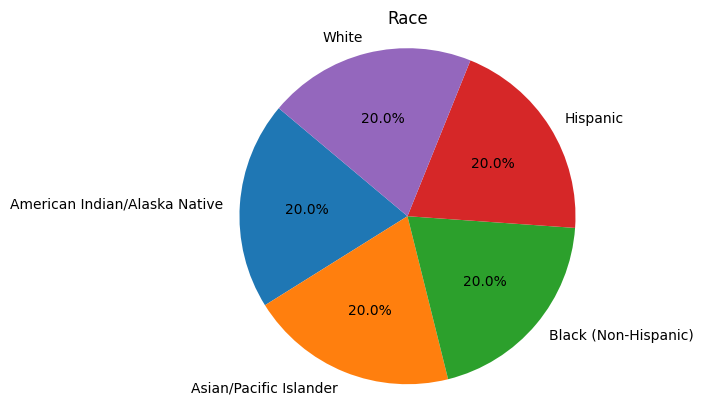

In [ ]:
plt.pie(race_counts, labels=race_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Race')
plt.axis('equal')
plt.show()

We can see that all the races are equally distributed in df. This is to be exepected since the dataset has been created using estimation.

Exploring the County column

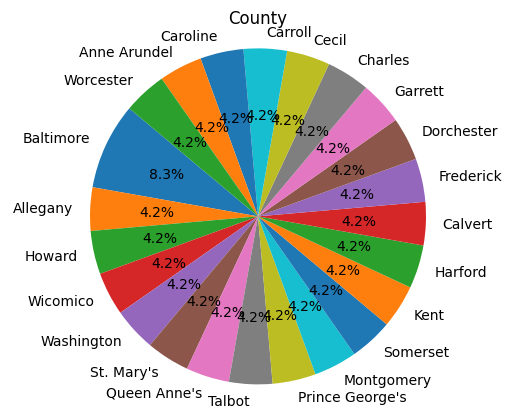

In [ ]:
county_counts = df['LocationDesc'].value_counts()

plt.pie(county_counts, labels=county_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('County')
plt.axis('equal')
plt.show()

In [ ]:
df.nunique()

,0
Year,21
LocationDesc,23
Topic,5
Data_Value,11234
Confidence_limit_Low,10629
Confidence_limit_High,11982
age_group,2
Race,6
Sex,3
LocationID,24


In [ ]:
#there are 23 counties in md and 23 locationDesc but there are 24 LocationID unique values
#printing what each LocationID maps to
for val in df["LocationID"].unique():
  filtered_rows = df[df['LocationID'] == val]

  if filtered_rows['LocationDesc'].nunique() == 1:
    unique_value = filtered_rows['LocationDesc'].iloc[0]
    print(val,"->", unique_value)


24001.0 -> Allegany
24009.0 -> Calvert
24003.0 -> Anne Arundel
24005.0 -> Baltimore
24011.0 -> Caroline
24013.0 -> Carroll
24015.0 -> Cecil
24017.0 -> Charles
24023.0 -> Garrett
24019.0 -> Dorchester
24021.0 -> Frederick
24025.0 -> Harford
24027.0 -> Howard
24029.0 -> Kent
24039.0 -> Somerset
24031.0 -> Montgomery
24033.0 -> Prince George's
24041.0 -> Talbot
24035.0 -> Queen Anne's
24037.0 -> St. Mary's
24043.0 -> Washington
24045.0 -> Wicomico
24047.0 -> Worcester
24510.0 -> Baltimore


We can observe that both 24005.0 and 24510.0 map to Baltimore. This coupled with the fact that baltimore has twice as much data shows that Baltimore is overrepresented here. (This may be done intentionally due to the size of Baltimore)



# Seperating Dataset

# How the Data is to be Filtered
The way the dataset is structured allows for people to filter the race and sex column to find what they’re looking for. They have also aggregated the data for race and sex which can be seen having “Overall” for race and sex. As a result of this to find the data that makes distinctions based on sex we filter the data down to rows which have “Overall” in race and vice versa for race. To find the data that is not sectioned based on race and sex we filter to rows where the race and sex is “Overall”.

In [ ]:
#the data is sectioned by year, county, and race
df_race = df[df['Sex'] == 'Overall'].reset_index()
df_race = df_race.drop(columns=['Sex'])
df_race.isna().sum()
df_race

,index,Year,LocationDesc,Topic,Data_Value,Confidence_limit_Low,Confidence_limit_High,age_group,Race,LocationID
0,2,1999,Allegany,All heart disease,NaN,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,24001.0
1,3,2013,Allegany,All heart disease,NaN,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,24001.0
2,4,2014,Allegany,All heart disease,NaN,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,24001.0
3,5,2005,Allegany,All heart disease,NaN,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,24001.0
4,6,2012,Allegany,All heart disease,NaN,NaN,NaN,Ages 35-64 years,American Indian/Alaska Native,24001.0
...,...,...,...,...,...,...,...,...,...,...
30235,40315,2006,Baltimore,Heart failure,385.9,339.0,432.8,Ages 65 years and older,White,24510.0
30236,40316,2013,Baltimore,Heart failure,367.7,323.1,410.2,Ages 65 years and older,White,24510.0
30237,40317,2004,Baltimore,Heart failure,394.5,356.9,436.5,Ages 65 years and older,White,24510.0
30238,40318,2005,Baltimore,Heart failure,388.7,348.7,439.1,Ages 65 years and older,White,24510.0


In [ ]:
#the data is sectioned by year, county, and sex
df_sex = df[df['Race'] == 'Overall'].reset_index()
df_sex = df_sex.drop(columns=['Race'])
df_sex.isna().sum()
df_sex

,index,Year,LocationDesc,Topic,Data_Value,Confidence_limit_Low,Confidence_limit_High,age_group,Sex,LocationID
0,0,2010,Allegany,All stroke,18.2,15.1,22.9,Ages 35-64 years,Men,24001.0
1,1,2013,Allegany,All stroke,17.9,14.4,21.7,Ages 35-64 years,Men,24001.0
2,107,2017,Allegany,All heart disease,126.4,113.3,141.6,Ages 35-64 years,Overall,24001.0
3,108,2016,Allegany,All heart disease,128.6,115.0,144.5,Ages 35-64 years,Overall,24001.0
4,109,2019,Allegany,All heart disease,128.3,110.9,145.6,Ages 35-64 years,Overall,24001.0
...,...,...,...,...,...,...,...,...,...,...
15115,39895,2009,Baltimore,Heart failure,355.2,316.1,394.3,Ages 65 years and older,Men,24510.0
15116,39896,2001,Baltimore,Heart failure,465.4,417.1,515.3,Ages 65 years and older,Men,24510.0
15117,39897,2000,Baltimore,Heart failure,467.4,413.2,534.5,Ages 65 years and older,Men,24510.0
15118,39898,2006,Baltimore,Heart failure,388.9,345.1,435.8,Ages 65 years and older,Men,24510.0


In [ ]:
#the data is sectioned by year, and county
df_overall = df[(df['Sex'] == 'Overall') & (df['Race'] == 'Overall')].reset_index()
df_overall = df_overall.drop(["Race", "Sex"], axis=1)
df_overall

,index,Year,LocationDesc,Topic,Data_Value,Confidence_limit_Low,Confidence_limit_High,age_group,LocationID
0,107,2017,Allegany,All heart disease,126.4,113.3,141.6,Ages 35-64 years,24001.0
1,108,2016,Allegany,All heart disease,128.6,115.0,144.5,Ages 35-64 years,24001.0
2,109,2019,Allegany,All heart disease,128.3,110.9,145.6,Ages 35-64 years,24001.0
3,110,2006,Allegany,All heart disease,130.0,112.4,147.2,Ages 35-64 years,24001.0
4,111,2003,Allegany,All heart disease,143.7,125.8,161.5,Ages 35-64 years,24001.0
...,...,...,...,...,...,...,...,...,...
5035,39685,2006,Baltimore,Heart failure,338.7,302.1,371.9,Ages 65 years and older,24510.0
5036,39686,2014,Baltimore,Heart failure,288.4,263.0,317.5,Ages 65 years and older,24510.0
5037,39687,1999,Baltimore,Heart failure,439.7,398.4,482.2,Ages 65 years and older,24510.0
5038,39688,2001,Baltimore,Heart failure,426.1,390.3,458.5,Ages 65 years and older,24510.0


# Checking for Missing Data

In [ ]:
df_overall.isna().sum()

,0
index,0
Year,0
LocationDesc,0
Topic,0
Data_Value,0
Confidence_limit_Low,0
Confidence_limit_High,0
age_group,0
LocationID,0


So, after filtering the data down to where the race is 'Overall' and sex is 'Overall', we can observe that the number of missing values is 0 for all the columns.

In [ ]:
df_sex.isna().sum()

,0
index,0
Year,0
LocationDesc,0
Topic,0
Data_Value,0
Confidence_limit_Low,0
Confidence_limit_High,0
age_group,0
Sex,0
LocationID,0


There is no missing data when the data is seperated by sex either

In [ ]:
df_race.isna().sum()

,0
index,0
Year,0
LocationDesc,0
Topic,0
Data_Value,9240
Confidence_limit_Low,9240
Confidence_limit_High,9240
age_group,0
Race,0
LocationID,0


We do have missing data  when  looking at the data seperated by race

# Exploring Race and Missingness

In [ ]:
#printing out the number of missing values for each race
for race in df_race["Race"].unique():
    nan_count = df_race[df_race  ['Race'] == race]['Data_Value'].isna().sum()
    print(race, nan_count)

American Indian/Alaska Native 4305
Overall 0
Asian/Pacific Islander 2520
Black (Non-Hispanic) 315
Hispanic 2100
White 0


In [ ]:
#printing out the percentage of missing values for each race
for race in df_race["Race"].unique():
    nan_count = df_race[df_race['Race'] == race]['Data_Value'].isna().sum()
    total_count = df_race[df_race['Race'] == race]['Data_Value'].count()

    if total_count > 0:
        percentage_nan = (nan_count / (nan_count + total_count)) * 100
    else:
        percentage_nan = 0

    print(race, "%: ", percentage_nan)

American Indian/Alaska Native %:  85.41666666666666
Overall %:  0.0
Asian/Pacific Islander %:  50.0
Black (Non-Hispanic) %:  6.25
Hispanic %:  41.66666666666667
White %:  0.0


From this we can see that significant portions of certain races are missing. We can also see that the Overall race value is missing no value because it has already been smoothed over for demographic groups

# Examining Correlations in Dataset 1

It is crucial that our variables do not exert any influence on each other when we perform analysis, because our model may struggle to distinguish the effects of each individual variable. When there is correlation, we also have redundant data as 1+ variables are being used to convey the same effect, leading to an unecessary increase in computation.

We first check if any of the potential features are corelated to each other.

An important detail to notice is that in df, most of the variables are categorical. Due to this, we can't perform df.corr() on the data directly. Instead, we must observe the pairwise correlation between the categorical variables using the chi^2 Test.

In [ ]:
from scipy.stats import chi2_contingency

In [ ]:
variables = ['Topic', 'LocationDesc', 'age_group', 'Race', 'Sex']
for i in range(len(variables)):
    for j in range(i + 1, len(variables)):
        var1, var2 = variables[i], variables[j]
        contingency_table = pd.crosstab(df[var1], df[var2])
        chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
        print(f"Chi-Square Test between {var1} and {var2}:")
        print(f"P-Value: {p_value}")

Chi-Square Test between Topic and LocationDesc:
P-Value: 1.0
Chi-Square Test between Topic and age_group:
P-Value: 1.0
Chi-Square Test between Topic and Race:
P-Value: 1.0
Chi-Square Test between Topic and Sex:
P-Value: 1.0
Chi-Square Test between LocationDesc and age_group:
P-Value: 1.0
Chi-Square Test between LocationDesc and Race:
P-Value: 1.0
Chi-Square Test between LocationDesc and Sex:
P-Value: 1.0
Chi-Square Test between age_group and Race:
P-Value: 1.0
Chi-Square Test between age_group and Sex:
P-Value: 1.0
Chi-Square Test between Race and Sex:
P-Value: 0.0


Running pairwise chi^2 tests on each combination of categorical variables, we see that all pairs expcept Race and Sex have a p-value of 1.0. Under any reasonable confidence level α, p > a and so the Null Hypothesis (There exists a correlation) is rejected, meaning the categories are independent from each other.

For the relation between Race and Sex however, the p-value is 0. This is surprising to see as it means that Race and Sex are correlated to each other. To further understand this corelation, we can now create dummy variables using pd.get_dummies and create a correlation matrix for all the categories.

pd.get_dummies(...) performs the same actions as One-hot encoding, wherein each unique value for a categorical feature becomes a binary vector. Using these vectors, we can create a correlation matrix to plot a heatmap.

<Axes: >

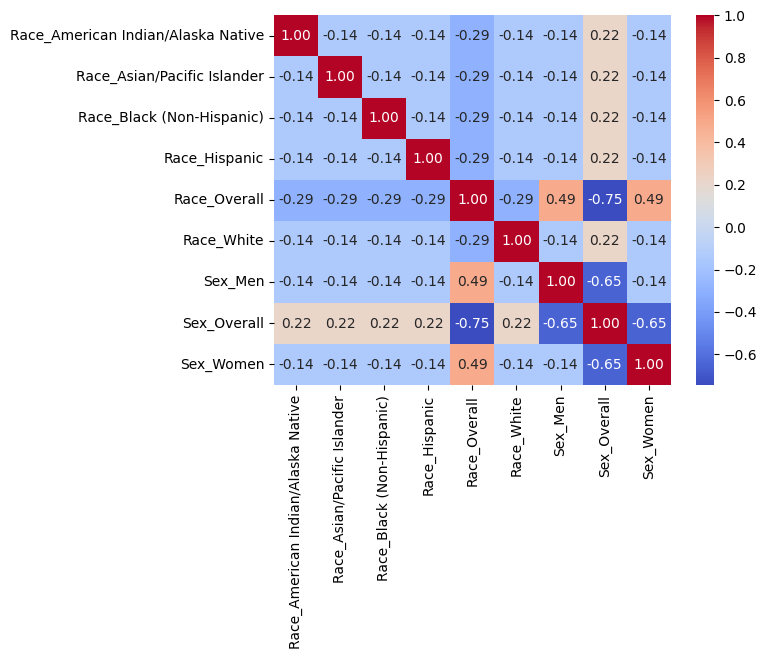

In [ ]:
df_race_sex_no_dv = pd.get_dummies(df, columns=['Race', 'Sex'])
df_race_sex_no_dv = df_race_sex_no_dv.drop(columns=['Year','Data_Value', 'LocationID', 'Confidence_limit_Low', 'Confidence_limit_High', 'Topic', 'LocationDesc', 'age_group'])
sns.heatmap(df_race_sex_no_dv.corr(), fmt='.2f', annot = True, cmap='coolwarm')

We can see that the majority of the correlation is coming from Race_Overall and Sex_Overall. The Overall columns are aggreation columns which are not needed since we are looking at the effect of each category type. So we can drop them and plot a heatmap again.

<Axes: >

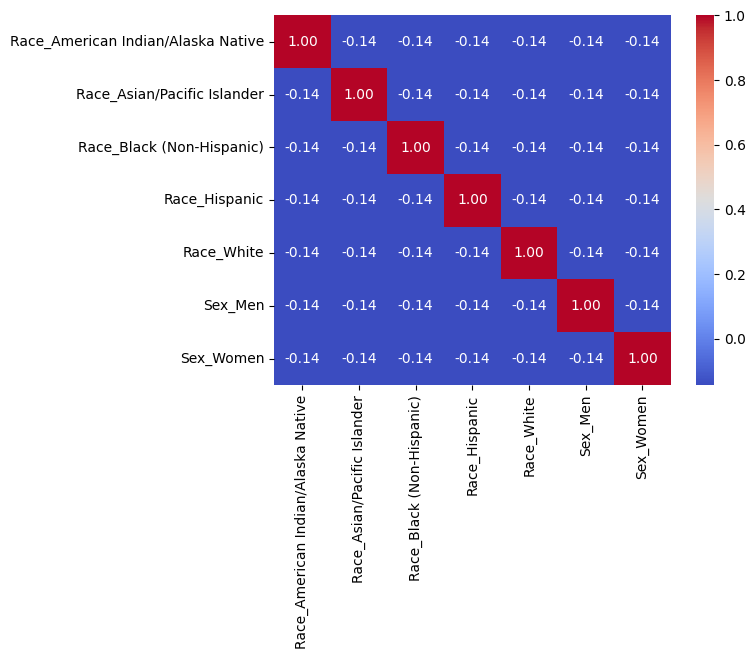

In [ ]:
df_race_sex_no_dv_overall = pd.get_dummies(df, columns=['Race', 'Sex'])
df_race_sex_no_dv_overall = df_race_sex_no_dv_overall.drop(columns=['Year','Data_Value', 'LocationID', 'Confidence_limit_Low', 'Confidence_limit_High', 'Topic', 'LocationDesc', 'age_group', 'Race_Overall', 'Sex_Overall'])
sns.heatmap(df_race_sex_no_dv_overall.corr(), fmt='.2f', annot = True, cmap='coolwarm')

This is along the lines of what we expect, Race and Sex do not have distinct correlation.

From the correlation heatmap and chi^2 tests, we see that for the all variables are independent from each other. This can be seen by looking at the colors for each cell, which roughly correspond to a correlation coefficient of 0 in the colorbar. This is good as it means that the effect of each variable is not influence by any other variable.

Next, let's try to see the effect of our variables on the mortality rate

<Axes: >

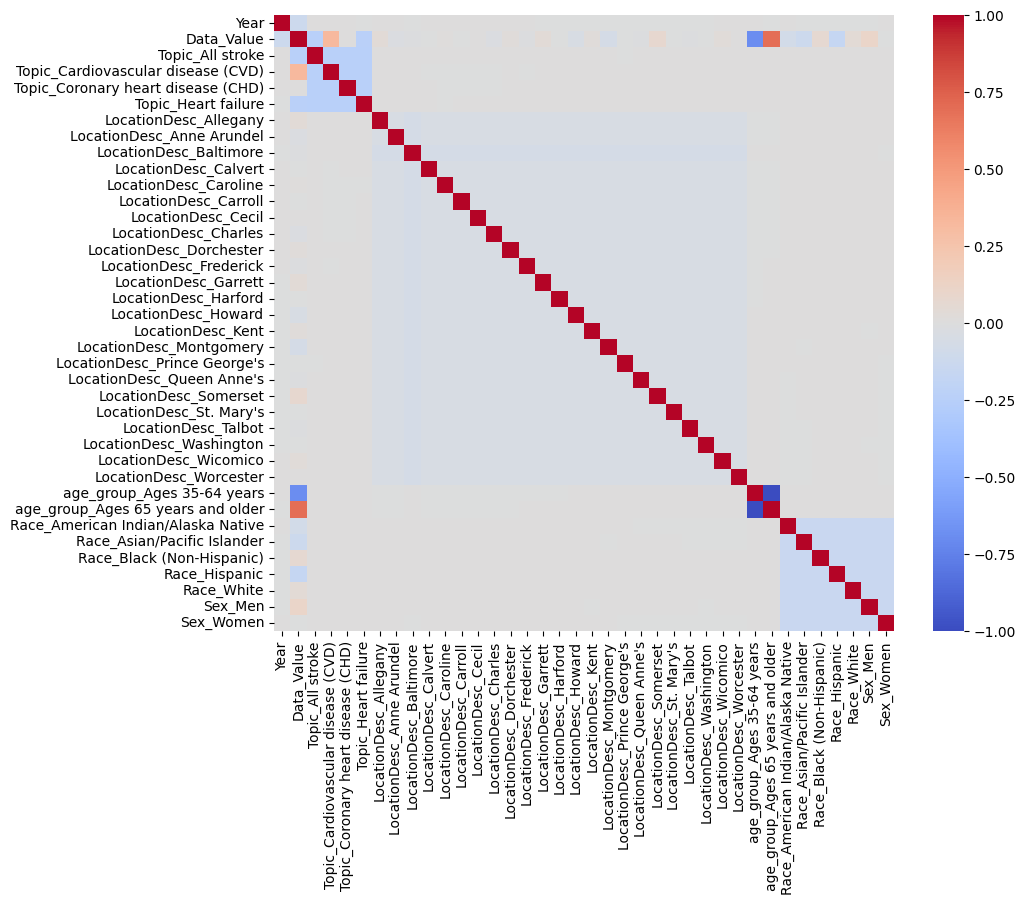

In [ ]:
df_with_dummies = pd.get_dummies(df, columns=['Topic', 'LocationDesc', 'age_group', 'Race', 'Sex'])
df_with_dummies = df_with_dummies.drop(columns=['LocationID', 'Confidence_limit_Low', 'Confidence_limit_High', 'Topic_All heart disease', 'Sex_Overall', 'Race_Overall', ])
plt.figure(figsize=(10, 8))

sns.heatmap(df_with_dummies.corr(), cmap='coolwarm')

The effects of each variable on Mortality can be seen in the 2nd row/column corresponding to Data_Value.

There doesn't appear to be many strong correlations with the exception of the age_group categories. It appears that lower ages have a negative correlation with the mortality rate while higher ages are more positively correlated with mortality rates. This of course is expected as the older one gets, the higher the chance of death.

It also appears that there is variation in mortality based on the county. This is interesting as it may suggest that there is a weak but non-negligble environmental/geographical relation with heart disease.

Similarly, there is weak variation in Race and Sex. For example, Sex_Men has a positive correlation with heart disease, while Sex_Female is slightly negative. It implies that Men are positively linked (more likely) to heart disease while women are negatively linked (less likely) to heart disease.

In Race, it appears what Black (Non-Hispanic) and White have a slightly positive correlation with mortality, as opposed to the remaining races having a slight negative correlation. It might indicate that some races are more susceptible to heart diesease than others.

Year too has a weak negative correaltion with Mortality. This again is expected as we expect fewer people die from diseases as time goes on due to improvements in healthcare.

These effects might be more pronounced if the data was standardized since mortality has a large range.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_value_scaled = scaler.fit_transform(df_with_dummies[['Data_Value']])
df_with_dummies['data_value_scaled'] = data_value_scaled

<Axes: >

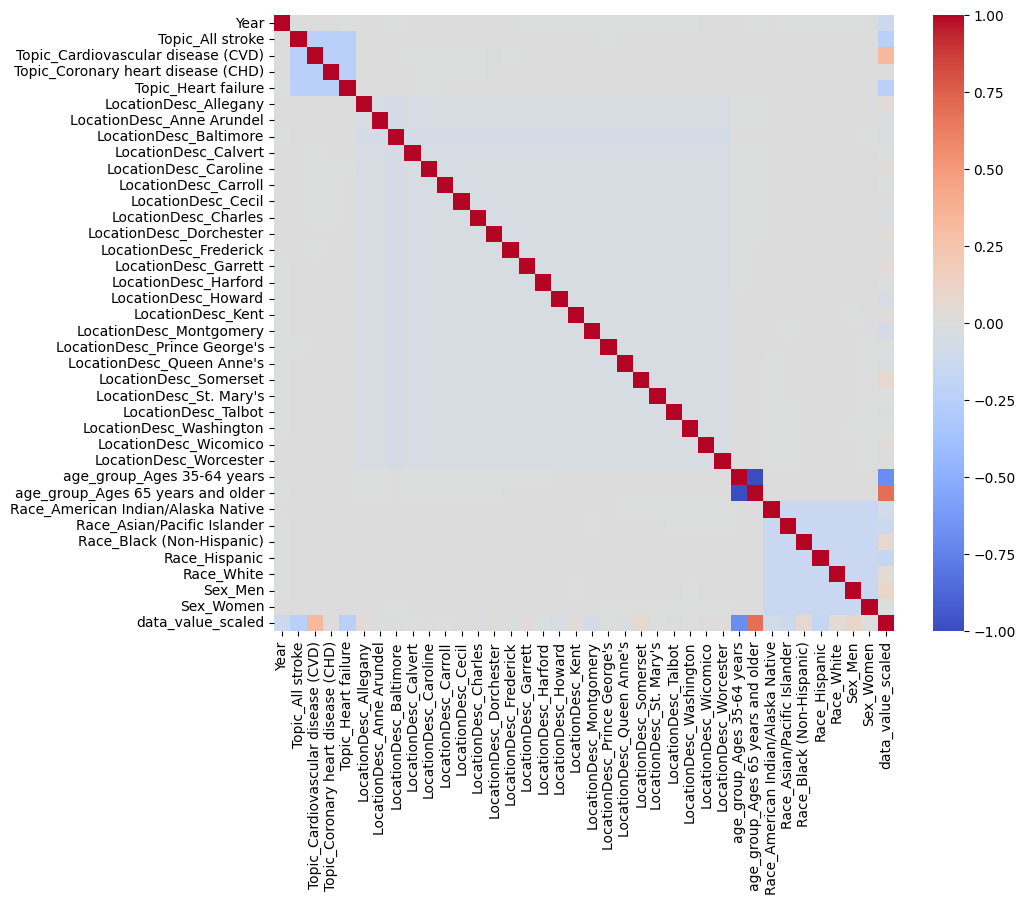

In [ ]:
# df_with_dummies_no_loc = pd.get_dummies(df, columns=['Topic', 'LocationDesc', 'age_group', 'Race', 'Sex'])
df_with_dummies = df_with_dummies.drop(columns=['Data_Value'])
plt.figure(figsize=(10, 8))
sns.heatmap(df_with_dummies.corr(), cmap='coolwarm')

As expected, the effect of our variables is more pronounced when Data_Value is scaled using MinMaxScaler (observe cells in the last row/column).

Most cells in the 'data_value_scaled' are considerably darker than the previous heatmap, meaning all the relationships identified earlier must be even stronger

# Effect of Race and Sex on Mortality

To confirm the results from the heatmaps, we decided to observe the effect that Race and Sex might poentially have on mortality. The resulting box plots were drawn:

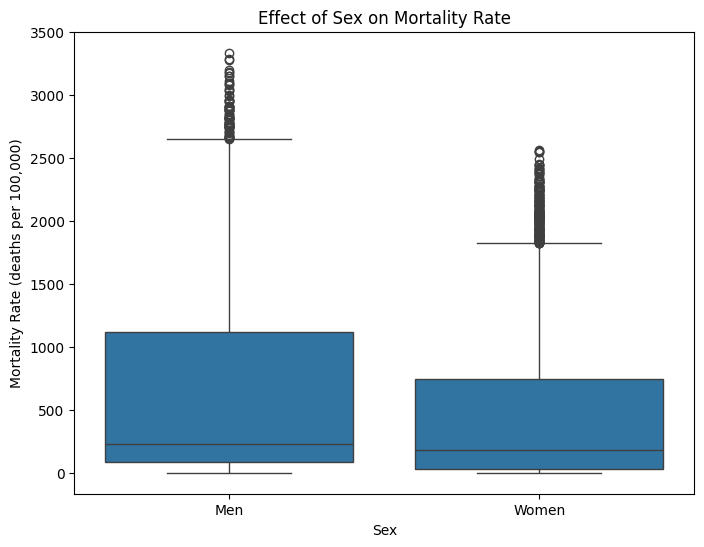

In [ ]:
# Boxplot
df_sex_mf = df_sex[df_sex['Sex'].isin(['Men', 'Women'])]
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_sex_mf, x="Sex", y="Data_Value")
plt.title("Effect of Sex on Mortality Rate")
plt.xlabel("Sex")
plt.ylabel("Mortality Rate (deaths per 100,000)")
plt.show()

From the plots we see that Men have a higher mortality from Heart Diseases than Women

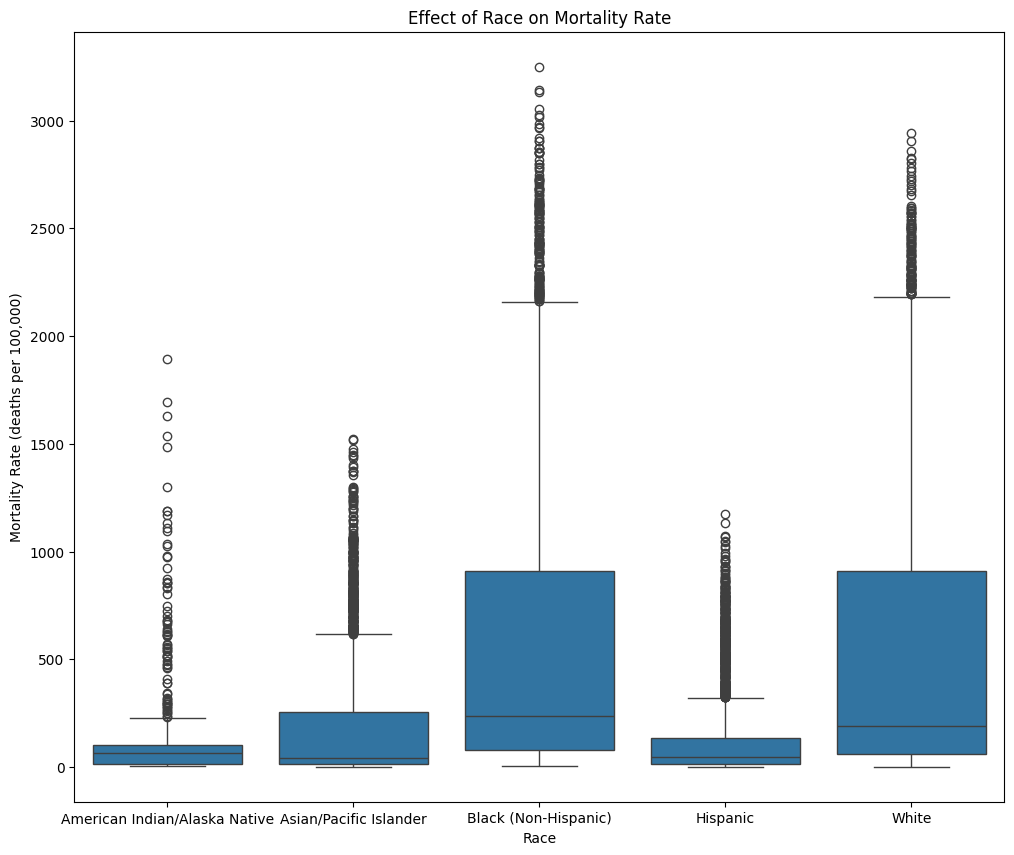

In [ ]:
df_race_filtered = df_race[df_race['Race'].isin(['American Indian/Alaska Native',
       'Asian/Pacific Islander', 'Black (Non-Hispanic)', 'Hispanic',
       'White'])]
plt.figure(figsize=(12, 10))
sns.boxplot(data=df_race_filtered, x="Race", y="Data_Value")
plt.title("Effect of Race on Mortality Rate")
plt.xlabel("Race")
plt.ylabel("Mortality Rate (deaths per 100,000)")
plt.show()

From the plots we see that the Black (Non-Hispanic) and White races have a higher mortality from Heart Diseases than other race groups

# First Test

For the first Hypothesis Test, we are using the ANOVA test to see if there is difference in the means of "Data_Value" (which is the mortality rate) for different topics (kinds of heart disease). We are essentially trying to see if the different types of heart dieseases have an effect on the mortality rate. An ANOVA Test is required because we are comparing the means of multiple groups

Null Hypothesis: There is no difference in "Data_Value" for the different kinds of heart diseases.

Alternative Hypothesis: There is a difference in "Data_Value" for the different kinds of heart diseases.

We are setting alpha to 0.01.


Types of Heart Diseases (Topics):
['All stroke' 'All heart disease' 'Coronary heart disease (CHD)'
 'Cardiovascular disease (CVD)' 'Heart failure']
F-statistic: 394.7155311884273, p-value: 3.6936075074683683e-296


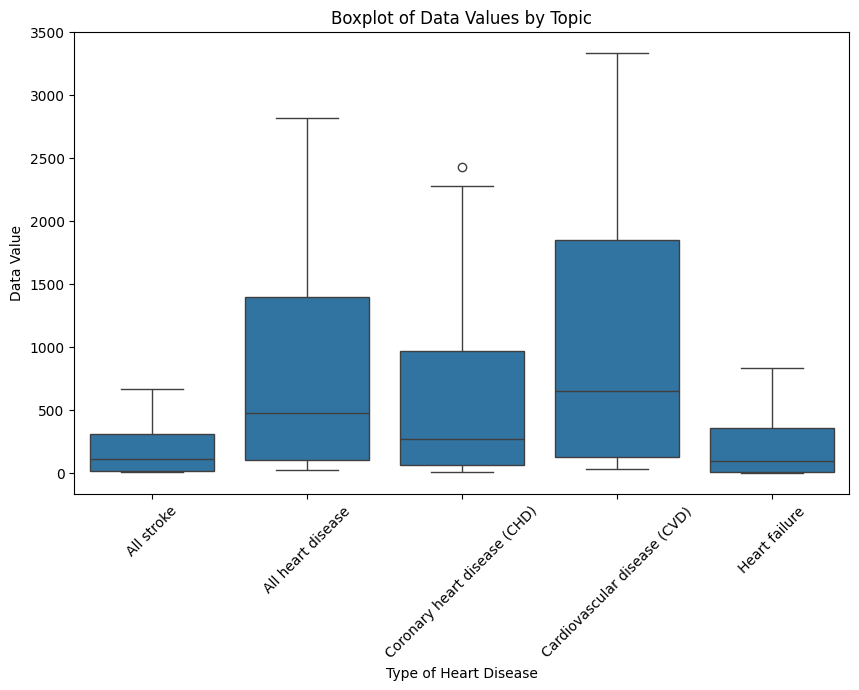

In [ ]:
print("Types of Heart Diseases (Topics):")
print(df_sex['Topic'].unique())

#Splitting the dataset using "Topic"
df_overall_all_stroke =df_overall[df_overall['Topic'] == 'All stroke']
df_overall_all_heart_disease = df_overall[df_overall['Topic'] == 'All heart disease']
df_overall_CHD = df_overall[df_overall['Topic'] == 'Coronary heart disease (CHD)']
df_overall_CVD = df_overall[df_overall['Topic'] == 'Cardiovascular disease (CVD)' ]
df_overall_heart_failure = df_overall[df_overall['Topic'] == 'Heart failure']

# Performing the ANOVA test
f_statistic, p_value = stats.f_oneway(df_overall_all_stroke['Data_Value'], df_overall_all_heart_disease['Data_Value'],df_overall_CHD['Data_Value'],
                                      df_overall_CVD['Data_Value'],df_overall_heart_failure['Data_Value'])

print(f"F-statistic: {f_statistic}, p-value: {p_value}")


# Create a boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Topic', y='Data_Value', data=df_sex)
plt.title('Boxplot of Data Values by Topic')
plt.xlabel('Type of Heart Disease')
plt.ylabel('Data Value')
plt.xticks(rotation=45)
plt.show()

Given that the p-value is significantly smaller than the alpha level, we reject the null hypothesis. This indicates a significant difference in "Data_Value" among the different types of heart diseases. This can be seen in the box-plots above.

In conclusion, the mean mortality rate varies across the various types of heart diseases. Notably, there are outliers present in the data for Coronary heart disease. Additionally, the median, 75th percentile and maybe even the 25th percentile values for Cardiovascular Disease (CVD) are significantly higher than those for the other types of heart diseases.

# Visualizing Dataset 2
Analyzing how fitness levels have improved over time in each county of Maryland can provide valuable insights into health trends. A time-series plot is particularly effective for visualizing such temporal data, as it clearly illustrates changes and patterns across years.

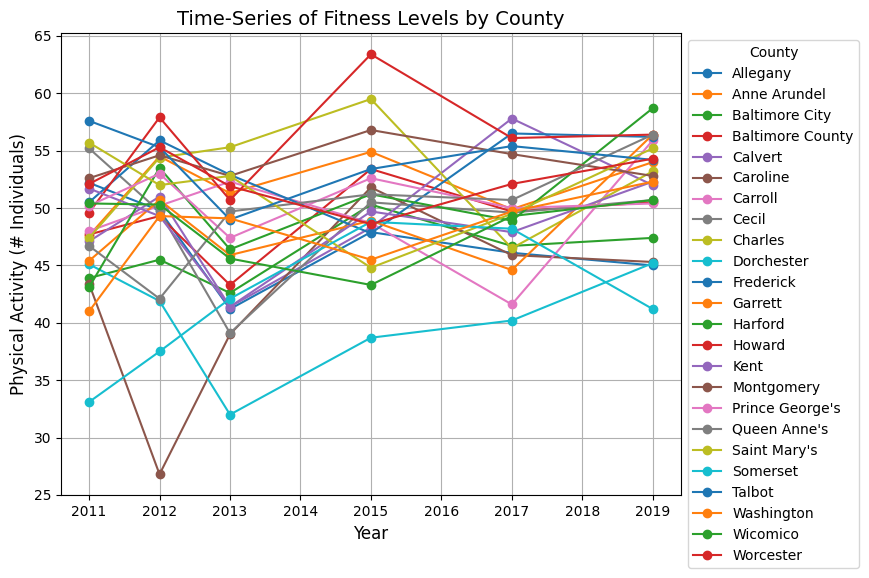

In [ ]:
physical_df_filtered_grouped = physical_df_filtered.groupby('Jurisdiction')
plt.figure(figsize=(8, 6))
for county, group in physical_df_filtered_grouped:
  plt.plot(group['Year'], group['Value'], label=county, marker='o')

plt.title("Time-Series of Fitness Levels by County", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Physical Activity (# Individuals)", fontsize=12)
plt.legend(title="County", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

Although there is appreciable variation in the plot, the overall trend indicates a positive shift, with the # of Individuals who take part in physical activity showing an upward trajectory over the observed time-range. It suggests that despite some fluctuations, there is a general increase in engagement with physical activities.

# Second Test

In the second test, we are first using a second dataset on physical activity to find what counties had an increase in physical activity from 2011 to 2019. Then we are using a paired T-test on the year 2011 to 2019 to see if there was a change in mortality rates ("Data_Value" column) in the counties which had an increase in physical activity.

Null Hypothesis: There is no difference in "Data_Value" for the counties with increased physical activity from 2011 to 2019

Alternative Hypothesis: There is a difference in "Data_Value" for the counties with increased physical activity from 2011 to 2019

We are setting the alpha to 0.01.

We are first cleaning the data to the years we want alongside filtering to the aggregated race category

In [ ]:
physical_df = pd.read_csv("/content/SHIP_Increase_Physical_Activity_2011-2019.csv")

physical_df = physical_df.drop("Measure", axis=1)

In [ ]:
physical_df_filtered = physical_df[
    (physical_df['Year'].isin([2011, 2019])) &
    (physical_df['Race/ ethnicity'] == 'All races/ ethnicities (aggregated)')
]
physical_df_filtered.reset_index().drop("index", axis = 1)

,Jurisdiction,Value,Race/ ethnicity,Year
0,State,52.2,All races/ ethnicities (aggregated),2019
1,Allegany,45.0,All races/ ethnicities (aggregated),2019
2,Anne Arundel,54.0,All races/ ethnicities (aggregated),2019
3,Baltimore County,50.5,All races/ ethnicities (aggregated),2019
4,Calvert,52.0,All races/ ethnicities (aggregated),2019
5,Caroline,45.3,All races/ ethnicities (aggregated),2019
6,Carroll,55.9,All races/ ethnicities (aggregated),2019
7,Cecil,50.7,All races/ ethnicities (aggregated),2019
8,Charles,53.2,All races/ ethnicities (aggregated),2019
9,Dorchester,45.2,All races/ ethnicities (aggregated),2019


Next, we are calculating the change in physical activity between 2011 and 2019 and plotting the change with a line at an increase of 5

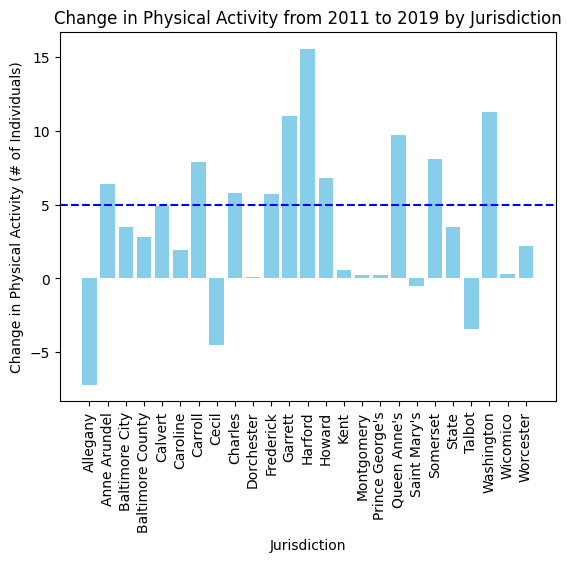

In [ ]:
pivot_df = physical_df_filtered.pivot_table(
    index='Jurisdiction',
    columns='Year',
    values='Value'
).reset_index()

pivot_df.columns = ['Jurisdiction', 'Value_2011', 'Value_2019']

pivot_df['Change'] = pivot_df['Value_2019'] - pivot_df['Value_2011']
plt.bar(pivot_df['Jurisdiction'], pivot_df['Change'], color='skyblue')
plt.axhline(y=5, color='blue', linestyle='--', linewidth=1.5)
plt.xticks(rotation=90)
plt.xlabel('Jurisdiction')
plt.ylabel('Change in Physical Activity (# of Individuals)')
plt.title('Change in Physical Activity from 2011 to 2019 by Jurisdiction')
plt.show()

We decided to use 5 as the cutoff value for the counties to study

In [ ]:
#list of counties with 5+ change from 2011 to 2019
sig_physical_change = pivot_df[pivot_df['Change'] >= 5].reset_index().drop("index", axis=1)
sig_physical_change

,Jurisdiction,Value_2011,Value_2019,Change
0,Anne Arundel,47.6,54.0,6.4
1,Carroll,48.0,55.9,7.9
2,Charles,47.4,53.2,5.8
3,Frederick,50.5,56.2,5.7
4,Garrett,45.4,56.4,11.0
5,Harford,43.1,58.7,15.6
6,Howard,49.6,56.4,6.8
7,Queen Anne's,46.7,56.4,9.7
8,Somerset,33.1,41.2,8.1
9,Washington,41.0,52.3,11.3


We are splitting the df_overall(filtered_csv where the race and sex are both 'Overall') into two dataframes (for the years 2011 and 2019). We are filtering the topics to "All heart disease."
We are grouping the data by counties and calculating the mean for the mortality rates ('Data_Value') so that we get an average of the mortality rates for the two different age groups by county.
After this, we are filtering the dataset down to include only those counties which are in the "sig_physical_change".
Thus, we are trying to find if physical activities have an effect on the mortality rates for different counties from 2011 to 2019.

In [ ]:
#Filtering the dataset to years 2011 & 2019
df_overall_11 = df_overall[(df_overall['Year'] == 2011) & (df_overall['Topic'] == 'All heart disease')].sort_values(by=['Year', 'LocationDesc'])
df_overall_19 = df_overall[(df_overall['Year'] == 2019) & (df_overall['Topic'] == 'All heart disease')].sort_values(by=['Year', 'LocationDesc'])

df_overall_11_mean = df_overall_11.groupby('LocationDesc')['Data_Value'].mean().reset_index()
df_overall_19_mean = df_overall_19.groupby('LocationDesc')['Data_Value'].mean().reset_index()
merged_means = pd.merge(df_overall_11_mean, df_overall_19_mean, on='LocationDesc', suffixes=('_2011', '_2019'))

# Assuming sig_physical_change is your list of locations
merged_means = merged_means[merged_means['LocationDesc'].isin(sig_physical_change["Jurisdiction"])]
merged_means

,LocationDesc,Data_Value_2011,Data_Value_2019
1,Anne Arundel,610.05,570.20
5,Carroll,622.95,585.15
7,Charles,664.05,571.45
9,Frederick,604.75,542.65
10,Garrett,719.10,734.05
11,Harford,625.80,571.35
12,Howard,472.05,426.40
16,Queen Anne's,565.75,564.90
17,Somerset,987.20,907.45
20,Washington,678.75,631.25


In [ ]:
# Perform the paired t-test
t_statistic, p_value = stats.ttest_rel(merged_means['Data_Value_2011'], merged_means['Data_Value_2019'])

# Output the results
print(f"T-statistic: {t_statistic}, P-value: {p_value}")

T-statistic: 4.341413390383205, P-value: 0.0018735931821840352


In conclusion, we found that the resulting p-value is significantly smaller than the alpha value of 0.01 so we reject the null hypothesis and accept the alternative hypothesis that the counties that experienced a increase in physical activity from 2011 to 2019 have experienced a change in mortality rates

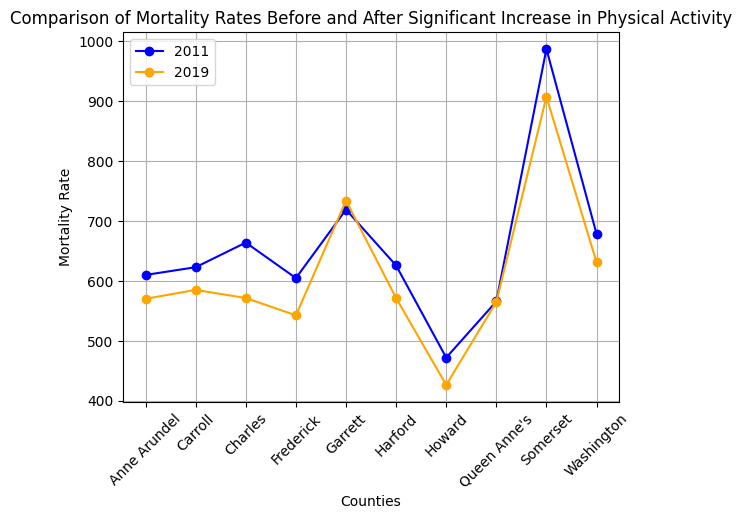

In [ ]:
plt.plot(merged_means['LocationDesc'], merged_means['Data_Value_2011'], marker='o', label='2011', color='blue')
plt.plot(merged_means['LocationDesc'], merged_means['Data_Value_2019'], marker='o', label='2019', color='orange')
plt.xlabel('Counties')
plt.ylabel('Mortality Rate')
plt.title('Comparison of Mortality Rates Before and After Significant Increase in Physical Activity')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Visualizing Income and Mortality in Maryland
Finanical status is another key factor that can determine mortality. Here, we will try to visualize the effect of economic status on mortality of heart diseases

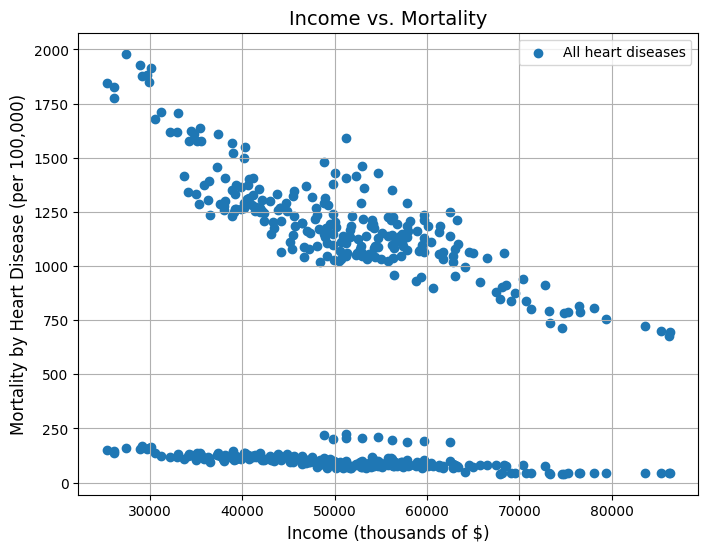

In [ ]:
df_overall_financial = df_overall[(df_overall['Year'] >= 2010) & (df_overall['Year'] <= 2020)]
df_merged = pd.merge(df_overall_financial , financial_df,
                     left_on=['Year', 'LocationDesc'],
                     right_on=['Year', 'County'],
                     how='inner')

df_merged = df_merged.drop(columns=['Confidence_limit_Low', 'LocationID', 'County', 'Confidence_limit_High'])
df_merged = df_merged[~df_merged['Data_Value'].isna()]
df_merged = df_merged [df_merged ['Topic'].isin(['All heart disease',])]

plt.figure(figsize=(8, 6))
plt.scatter(df_merged['Income'], df_merged['Data_Value'], label='All heart diseases', marker='o')

plt.title("Income vs. Mortality", fontsize=14)
plt.xlabel("Income (thousands of $)", fontsize=12)
plt.ylabel("Mortality by Heart Disease (per 100,000)", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

The scatter plot shows a clear negative correlation between income and mortality due to heart disease, indicating that higher income levels are associated with lower rates of heart disease mortality. This suggests that economic factors may play a role in heart-disease based mortality.

# Third Test

Hypothesis: Null Hypothesis (H0): There is no significant difference in income levels between counties with high and low mortality rates for stroke in the age groups 35-64 and 65+ in Maryland from 2010 to 2020.

Alternative Hypothesis (H1): There is a significant difference in income levels between counties with high and low mortality rates for stroke in the age groups 35-64 and 65+ in Maryland from 2010 to 2020.

Alpha value of 0.05

In [ ]:
#3rd Hypothesis

financial_df = pd.read_csv("/content/Maryland_Total_Personal_Income__Thousands_of_Current_Dollars___2010-2022.csv")
financial_df = financial_df.drop(columns=['MARYLAND', 'Date created'])
financial_df = financial_df.iloc[:10]
financial_df = pd.melt(financial_df, id_vars=["Year"],
                         var_name="County",
                         value_name="Income")

financial_df['County'] = financial_df['County'].str.replace(' County', '', regex=False)

df_overall_financial = df_overall[(df_overall['Year'] >= 2010) & (df_overall['Year'] <= 2020)]
df_merged = pd.merge(df_overall_financial , financial_df,
                     left_on=['Year', 'LocationDesc'],
                     right_on=['Year', 'County'],
                     how='inner')

df_merged = df_merged.drop(columns=['Confidence_limit_Low', 'LocationID', 'County', 'Confidence_limit_High' ])
df_merged = df_merged [df_merged ['Topic'] == 'All stroke']
df_merged

,index,Year,LocationDesc,Topic,Data_Value,age_group,Income
10,129,2013,Allegany,All stroke,16.5,Ages 35-64 years,33017
11,130,2014,Allegany,All stroke,16.5,Ages 35-64 years,34505
12,131,2019,Allegany,All stroke,15.2,Ages 35-64 years,40687
13,134,2017,Allegany,All stroke,15.0,Ages 35-64 years,38180
14,135,2016,Allegany,All stroke,15.5,Ages 35-64 years,37320
...,...,...,...,...,...,...,...
2365,39616,2018,Baltimore,All stroke,347.5,Ages 65 years and older,59695
2366,39617,2013,Baltimore,All stroke,345.6,Ages 65 years and older,51192
2367,39622,2011,Baltimore,All stroke,308.0,Ages 65 years and older,49862
2368,39624,2010,Baltimore,All stroke,315.4,Ages 65 years and older,48811


In [ ]:
df_merged_35 = df_merged [df_merged ['age_group'] == 'Ages 35-64 years']
df_merged_35

,index,Year,LocationDesc,Topic,Data_Value,age_group,Income
10,129,2013,Allegany,All stroke,16.5,Ages 35-64 years,33017
11,130,2014,Allegany,All stroke,16.5,Ages 35-64 years,34505
12,131,2019,Allegany,All stroke,15.2,Ages 35-64 years,40687
13,134,2017,Allegany,All stroke,15.0,Ages 35-64 years,38180
14,135,2016,Allegany,All stroke,15.5,Ages 35-64 years,37320
...,...,...,...,...,...,...,...
2315,38779,2015,Baltimore,All stroke,31.6,Ages 35-64 years,54698
2316,38780,2011,Baltimore,All stroke,33.2,Ages 35-64 years,49862
2317,38783,2018,Baltimore,All stroke,31.8,Ages 35-64 years,59695
2318,38784,2012,Baltimore,All stroke,34.8,Ages 35-64 years,51260


In [ ]:
df_merged_65 = df_merged [df_merged ['age_group'] == 'Ages 65 years and older']
df_merged_65

,index,Year,LocationDesc,Topic,Data_Value,age_group,Income
60,968,2016,Allegany,All stroke,300.5,Ages 65 years and older,37320
61,969,2014,Allegany,All stroke,318.2,Ages 65 years and older,34505
62,971,2015,Allegany,All stroke,311.7,Ages 65 years and older,35510
63,974,2017,Allegany,All stroke,304.0,Ages 65 years and older,38180
64,977,2019,Allegany,All stroke,306.0,Ages 65 years and older,40687
...,...,...,...,...,...,...,...
2365,39616,2018,Baltimore,All stroke,347.5,Ages 65 years and older,59695
2366,39617,2013,Baltimore,All stroke,345.6,Ages 65 years and older,51192
2367,39622,2011,Baltimore,All stroke,308.0,Ages 65 years and older,49862
2368,39624,2010,Baltimore,All stroke,315.4,Ages 65 years and older,48811


With the datesets for ages 35-64 and 65+, we can now run the hypothesis tests

In [ ]:
from statsmodels.stats.weightstats import ztest
median_mortality_35_64 = df_merged_35['Data_Value'].median()
median_mortality_65_plus = df_merged_65['Data_Value'].median()


high_mortality_35_64 = df_merged_35[df_merged_35['Data_Value'] > median_mortality_35_64]
low_mortality_35_64 = df_merged_35[df_merged_35['Data_Value'] <= median_mortality_35_64]


high_mortality_65_plus = df_merged_65[df_merged_65['Data_Value'] > median_mortality_65_plus]
low_mortality_65_plus = df_merged_65[df_merged_65['Data_Value'] <= median_mortality_65_plus]


z_stat_35_64, p_val_35_64 = ztest(high_mortality_35_64['Income'], low_mortality_35_64['Income'])

# For 65+ age group
z_stat_65_plus, p_val_65_plus = ztest(high_mortality_65_plus['Income'], low_mortality_65_plus['Income'])

z_stat_35_64, p_val_35_64, z_stat_65_plus, p_val_65_plus

(-8.780587700873609,
 1.6262265163207292e-18,
 -3.47678832965042,
 0.0005074582711123621)

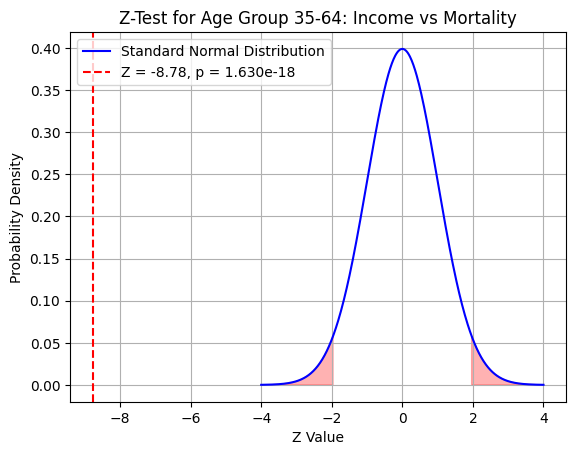

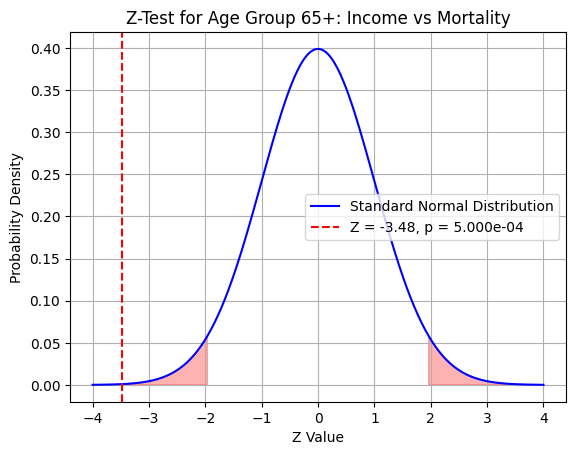

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


def plot_z_test(z_stat, p_value, title):
    z_range = np.linspace(-4, 4, 500)

    normal_curve = norm.pdf(z_range)

    plt.plot(z_range, normal_curve, label='Standard Normal Distribution', color='blue')
    plt.axvline(x=z_stat, color='red', linestyle='--', label=f'Z = {z_stat:.2f}, p = {p_value:.3e}')
    plt.fill_between(z_range, 0, normal_curve, where=(z_range <= -1.96) | (z_range >= 1.96), color='red', alpha=0.3)

    plt.title(title)
    plt.xlabel('Z Value')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_z_test(-8.78, 1.63e-18, 'Z-Test for Age Group 35-64: Income vs Mortality')
plot_z_test(-3.48, 0.0005, 'Z-Test for Age Group 65+: Income vs Mortality')


Z-Test Results: For Age Group 35-64: Z-Statistic: -8.78 P-Value: 1.63e-18 For Age Group 65+: Z-Statistic: -3.48 P-Value: 0.0005

Conclusion: For the age group 35-64: The p-value of 1.63e-18 is far below the 0.05 significance level, allowing us to reject the null hypothesis. This indicates a significant difference in income levels between counties with high and low mortality rates. Higher income is associated with lower mortality rates in this age group.

For the age group 65+: The p-value of 0.0005 is also below 0.05, allowing us to reject the null hypothesis for this age group as well. While the relationship between income and mortality is statistically significant, the effect size (as reflected by the Z-Statistic of -3.48) is smaller compared to the 35-64 age group.

Interpretation: In both age groups, higher income levels are correlated with lower mortality rates for stroke. The relationship is stronger in the age group 35-64, where income appears to have a more pronounced effect on reducing mortality rates.

# Merging Datasets
So far we have examined the effect of each dataset's variables one-by-one, but from this step onwards it will be beneficial to merge all the relevant features of each dataset into 1 master dataset. A single comprehensive dataset will allow for a more holistic training and will produce a single model rather than mutliple small models. By training our model on a combined dataset, we can be sure that the ML algorithms will attempt to learn interactions between each feature we are interested in.

In this analysis, the master dataset will comprise of the following features:
* County Location (Categorical, One-Hot Encoded)
* Heart Disease Type (Categorical, One-Hot Encoded)
* Age Group (Categorical, One-Hot Encoded)
* Race (Categorical, One-Hot Encoded)
* Sex (Categorical, One-Hot Encoded)
* Income (Continuous, Standardized)
* Physical Activity (Continuous, Standardized)

The trained model should be able to predict a single output value which is:
* Mortality Rate (Continuous, Standardized)




We have already attemped to merge datasets when conducting EDA, but for the purposes of separating EDA, Merging and ML training a new dataset will be created

In [ ]:
master_df = df
master_df = master_df.drop(columns =['Confidence_limit_Low', 'Confidence_limit_High', 'LocationID'])

financial_df = pd.read_csv("/content/Maryland_Total_Personal_Income__Thousands_of_Current_Dollars___2010-2022.csv")
financial_df = financial_df.drop(columns=['MARYLAND', 'Date created'])
financial_df = financial_df.iloc[:10]
financial_df = pd.melt(financial_df, id_vars=["Year"],
                         var_name="County",
                         value_name="Income")

financial_df['County'] = financial_df['County'].str.replace(' County', '', regex=False)

master_df = master_df[(master_df['Year'] >= 2010) & (master_df['Year'] <= 2020)]
master_df = pd.merge(master_df , financial_df,
                     left_on=['Year', 'LocationDesc'],
                     right_on=['Year', 'County'],
                     how='inner')
master_df = master_df.drop(columns = ['County'])

physical_df_filtered = physical_df[
    (physical_df['Year'].isin([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019])) &
    (physical_df['Race/ ethnicity'] == 'All races/ ethnicities (aggregated)')
]
physical_df_filtered.reset_index().drop("index", axis = 1)


master_df = pd.merge(master_df , physical_df_filtered[['Year', 'Jurisdiction', 'Value']],
                     left_on=['Year', 'LocationDesc'],
                     right_on=['Year', 'Jurisdiction'],
                     how='inner')

master_df = master_df.drop(columns = ['Jurisdiction'])
master_df.rename(columns={'Value': 'Physical Activity', 'Data_Value': 'Mortality', 'age_group':'Age_Group', 'LocationDesc':'County', 'Topic':'Disease Type'}, inplace=True)
master_df

,Year,County,Disease Type,Mortality,Age_Group,Race,Sex,Income,Physical Activity
0,2013,Allegany,All stroke,17.9,Ages 35-64 years,Overall,Men,33017,41.2
1,2013,Allegany,All heart disease,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall,33017,41.2
2,2012,Allegany,All heart disease,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall,32945,49.8
3,2011,Allegany,All heart disease,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall,32213,52.2
4,2019,Allegany,All heart disease,NaN,Ages 35-64 years,American Indian/Alaska Native,Overall,40687,45.0
...,...,...,...,...,...,...,...,...,...
10075,2012,Worcester,Heart failure,204.9,Ages 65 years and older,White,Overall,47380,55.3
10076,2015,Worcester,Heart failure,204.8,Ages 65 years and older,White,Overall,54118,48.6
10077,2011,Worcester,Heart failure,216.6,Ages 65 years and older,White,Overall,45459,52.1
10078,2013,Worcester,Heart failure,195.6,Ages 65 years and older,White,Overall,47851,51.9


In [ ]:
master_df.size

90720

In [ ]:
master_df.isna().sum()

,0
Year,0
County,0
Disease Type,0
Mortality,2460
Age_Group,0
Race,0
Sex,0
Income,0
Physical Activity,0


As can be seen 2460 values of the target are missing (NaN). Though the dataset is quite large, it might be better if we can somehow create new values through imputation rather than dropping NaN records.

To do this, we must first analyse the distribution of Data_value

In [ ]:
master_df.groupby('County')['Mortality'].describe()

,count,mean,std,min,25%,50%,75%,max
County,,,,,,,,
Allegany,270.0,523.700370,675.419350,6.9,71.400,177.85,907.225,2403.0
Anne Arundel,450.0,345.580444,456.122787,3.2,28.300,118.15,442.725,1822.5
Calvert,360.0,393.195278,547.557994,3.2,23.325,94.25,512.075,1957.5
Caroline,330.0,445.755758,557.633569,4.0,50.250,161.10,754.525,1955.9
Carroll,360.0,377.565556,519.605693,3.1,24.550,85.05,515.200,1972.0
Cecil,360.0,425.287500,578.617779,3.4,30.200,140.75,508.925,2120.6
Charles,420.0,342.601429,482.489074,2.8,26.900,104.75,405.850,1918.4
Dorchester,330.0,444.836061,574.452530,3.8,42.875,180.85,704.700,2056.7
Frederick,420.0,363.945714,468.649856,3.1,25.925,140.30,528.175,1794.3


Since the standard deviations for most counties are within reasonable bounds, we can perform mean imputation as a reasonable stdev indicates few outliers.

In [ ]:
mean_data_values = master_df.groupby(['Year', 'County'])['Mortality'].mean()
years = [2011, 2012, 2013, 2015, 2017, 2019]
counties = ['Allegany', 'Calvert', 'Anne Arundel', 'Caroline', 'Carroll', 'Cecil',
 'Charles', 'Garrett', 'Dorchester', 'Frederick', 'Harford', 'Howard', 'Kent',
 'Montgomery', "Prince George's", 'Somerset', 'Talbot', "Queen Anne's",
 'Washington', 'Wicomico', 'Worcester']
for year in years:
  for county in counties:
    master_df[(master_df['Year'] == year) & (master_df['County'] == county)] = master_df[(master_df['Year'] == year) & (master_df['County'] == county)].fillna(mean_data_values[year][county])

print(master_df.isna().sum())
master_df

Year                 0
County               0
Disease Type         0
Mortality            0
Age_Group            0
Race                 0
Sex                  0
Income               0
Physical Activity    0
dtype: int64


,Year,County,Disease Type,Mortality,Age_Group,Race,Sex,Income,Physical Activity
0,2013,Allegany,All stroke,17.900000,Ages 35-64 years,Overall,Men,33017,41.2
1,2013,Allegany,All heart disease,568.964444,Ages 35-64 years,American Indian/Alaska Native,Overall,33017,41.2
2,2012,Allegany,All heart disease,546.953333,Ages 35-64 years,American Indian/Alaska Native,Overall,32945,49.8
3,2011,Allegany,All heart disease,547.608889,Ages 35-64 years,American Indian/Alaska Native,Overall,32213,52.2
4,2019,Allegany,All heart disease,473.046667,Ages 35-64 years,American Indian/Alaska Native,Overall,40687,45.0
...,...,...,...,...,...,...,...,...,...
10075,2012,Worcester,Heart failure,204.900000,Ages 65 years and older,White,Overall,47380,55.3
10076,2015,Worcester,Heart failure,204.800000,Ages 65 years and older,White,Overall,54118,48.6
10077,2011,Worcester,Heart failure,216.600000,Ages 65 years and older,White,Overall,45459,52.1
10078,2013,Worcester,Heart failure,195.600000,Ages 65 years and older,White,Overall,47851,51.9


Now our dataset is not missing any values

# Feature Engineering

Before performing scaling, it is important to take a look at the underlying distributions of the data we have. This is most important for the continuous variables. One-Hot Encoded variables are really just binary vectors of categorical data, so there is no reason to examine their distribution.

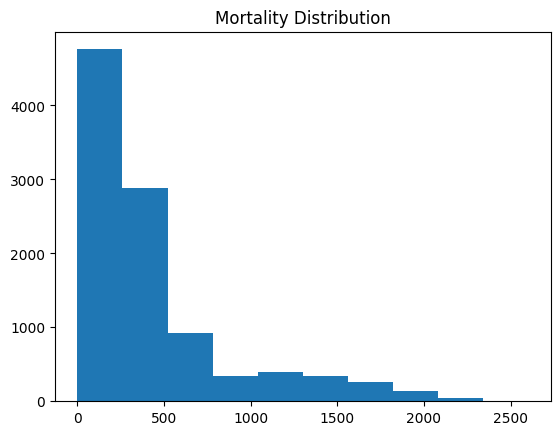

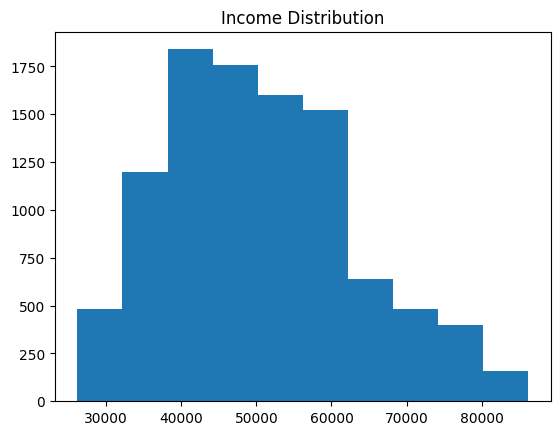

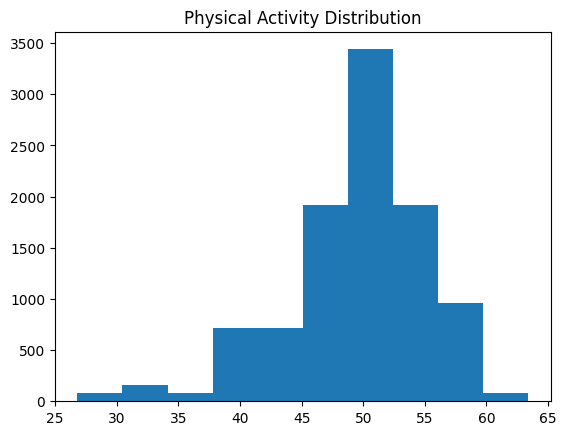

In [ ]:
plt.hist(master_df['Mortality'])
plt.title('Mortality Distribution')
plt.show()

plt.hist(master_df['Income'])
plt.title('Income Distribution')
plt.show()

plt.hist(master_df['Physical Activity'])
plt.title('Physical Activity Distribution')
plt.show()

We see that Mortality is close to being lognormally distributed, so it would be helpful for later ML algorithms if we perform a log-transform to this data to make our data range smaller. The logarithmic behavior does make sense as mortalities are usually represented on a logarithmic scale. This is due to the fact that mortality increases exponentially with respect to age.

All other continuous variables appear to be normally distribted.

In [ ]:
import numpy as np

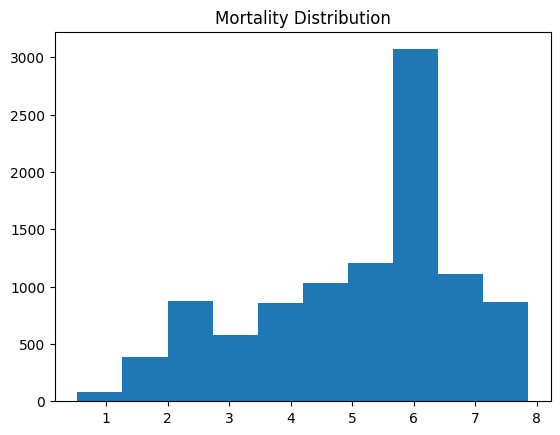

In [ ]:
master_df['Mortality'] = np.log(master_df['Mortality'])
plt.hist(master_df['Mortality'])
plt.title('Mortality Distribution')
plt.show()

## Filtering out American Indian/Alaska Native

When we analyzed the missing data in relation to race earlier, we found that ‘American Indian/Alaska Native Non-Hispanic/Latino’ had 85.416% of their mortality rate data missing. This was a significant portion of their data so we realized that using imputation for this race wouldn’t be possible and as a result we dropped the category.  

In [ ]:
master_df = master_df[master_df['Race'] != 'American Indian/Alaska Native']
master_df

,Year,County,Disease Type,Mortality,Age_Group,Race,Sex,Income,Physical Activity
0,2013,Allegany,All stroke,2.884801,Ages 35-64 years,Overall,Men,33017,41.2
31,2017,Allegany,All heart disease,4.839451,Ages 35-64 years,Overall,Overall,38180,46.1
32,2019,Allegany,All heart disease,4.854371,Ages 35-64 years,Overall,Overall,40687,45.0
33,2013,Allegany,All heart disease,4.870607,Ages 35-64 years,Overall,Overall,33017,41.2
34,2015,Allegany,All heart disease,4.852811,Ages 35-64 years,Overall,Overall,35510,47.9
...,...,...,...,...,...,...,...,...,...
10075,2012,Worcester,Heart failure,5.322522,Ages 65 years and older,White,Overall,47380,55.3
10076,2015,Worcester,Heart failure,5.322034,Ages 65 years and older,White,Overall,54118,48.6
10077,2011,Worcester,Heart failure,5.378052,Ages 65 years and older,White,Overall,45459,52.1
10078,2013,Worcester,Heart failure,5.276072,Ages 65 years and older,White,Overall,47851,51.9


# Primary Analysis

The first step before performing any type of Machine Learning Model/Analysis is to define the features and target variable for the model.

In the case of our master_df, all variables other than Mortality are feature variables, and Mortality itself is a target variable. Accordingly, X is set to the features, while y is set to the target

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
random_state= 42

y = master_df['Mortality']
X = master_df.drop(['Mortality'], axis=1)

With our features and targets set, it is now time to split the dataset. This step is key as we don't the model to overfit on all the data. This step will set aside a portion of the data for testing once a model has been trained. By evaluating the performance on unseen data, we can see if the model generalizing well.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

X_train

,Year,County,Disease Type,Age_Group,Race,Sex,Income,Physical Activity
3532,2011,Dorchester,Cardiovascular disease (CVD),Ages 35-64 years,Black (Non-Hispanic),Overall,37570,45.1
539,2015,Anne Arundel,Heart failure,Ages 35-64 years,Overall,Overall,61255,54.9
9295,2017,Wicomico,Heart failure,Ages 35-64 years,Black (Non-Hispanic),Overall,40172,49.3
9595,2012,Wicomico,Heart failure,Ages 65 years and older,White,Overall,34800,50.3
8912,2017,Washington,All heart disease,Ages 65 years and older,Overall,Overall,44187,49.7
...,...,...,...,...,...,...,...,...
6574,2015,Montgomery,All heart disease,Ages 65 years and older,Overall,Men,79358,56.8
5941,2019,Kent,All heart disease,Ages 35-64 years,Hispanic,Overall,60407,52.3
6170,2011,Kent,Cardiovascular disease (CVD),Ages 65 years and older,Black (Non-Hispanic),Overall,46743,51.7
1010,2012,Calvert,Coronary heart disease (CHD),Ages 35-64 years,Overall,Overall,53243,51.0


As mentioned earlier, data will be transformed, scaled and encoded to help with Machine learning. The following features will be modified here:

* County (Categorical, One-Hot Encoded)
* Disease Type (Categorical, One-Hot Encoded)
* Age Group (Categorical, One-Hot Encoded)
* Race (Categorical, One-Hot Encoded)
* Sex (Categorical, One-Hot Encoded)
* Income (Continuous, Standardized)
* Physical Activity (Continuous Standardized)
* Mortality (Continuous, Standardized)

We chose to make categorical features One-Hot encoded for two reasons. First, ML models usually only work on numerical data, so data like Disease Type, Race, Age and Sex will not work in these models. Furthermore, since the categorical features are not ordered, OHE will ensure the encoded variables are not ordered either.

One Hot Encoding and Standardization will only be fitted on the X_train data since we don't want information leaking into the X_test dataset. Once fitted, both X_train and X_test will be transformed based on the fitted values from X_train.

In [ ]:
encoder = OneHotEncoder(categories='auto', sparse_output=False)
scaler = StandardScaler()

encoded = encoder.fit(X_train[['County', 'Disease Type', 'Sex', 'Age_Group', 'Race']])
encoded = encoder.transform(X_train[['County', 'Disease Type', 'Sex', 'Age_Group', 'Race']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['County', 'Disease Type', 'Sex', 'Age_Group', 'Race']))

scaled = scaler.fit(X_train[['Income', 'Physical Activity']])
scaled = scaler.transform(X_train[['Income', 'Physical Activity']])
scaled_df = pd.DataFrame(scaled, columns=['Income_scaled', 'Physical Activity_scaled'])

X_train = pd.concat([encoded_df, scaled_df], axis=1)


encoded = encoder.transform(X_test[['County', 'Disease Type', 'Sex', 'Age_Group', 'Race']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['County', 'Disease Type', 'Sex', 'Age_Group', 'Race']))

scaled = scaler.transform(X_test[['Income', 'Physical Activity']])
scaled_df = pd.DataFrame(scaled, columns=['Income_scaled', 'Physical Activity_scaled'])

X_test = pd.concat([encoded_df, scaled_df], axis=1)

X_train, X_test

(      County_Allegany  County_Anne Arundel  County_Calvert  County_Caroline  \
 0                 0.0                  0.0             0.0              0.0   
 1                 0.0                  1.0             0.0              0.0   
 2                 0.0                  0.0             0.0              0.0   
 3                 0.0                  0.0             0.0              0.0   
 4                 0.0                  0.0             0.0              0.0   
 ...               ...                  ...             ...              ...   
 7051              0.0                  0.0             0.0              0.0   
 7052              0.0                  0.0             0.0              0.0   
 7053              0.0                  0.0             0.0              0.0   
 7054              0.0                  0.0             1.0              0.0   
 7055              0.0                  0.0             0.0              0.0   
 
       County_Carroll  County_Cecil  C

# ML Model

We decided on performing regression because it is well-suited for predicting continuous outcomes and uncovering relationships between variables. This is a perfect fit since Mortality is continuous.

Since Mortality is a continuous value, a regressive model would be able to predict the mortality of an input record that consists of Race, Age, Sex, County, Disease Type, Income and Physical Activity.

By creating a model using these relationships, regression will essentially help us in forecasting trends, as well as understand what features have the highest contribution to mortality.

## ML Models: Linear Regression

In [ ]:
# imports
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import cross_val_score


Linear Regression is the simplest and most interpretable model, making it an ideal starting point for investigating mortality. Linear Regression will assume a simple linear relationship between the features and the target, resulting in a easily interpretable results.

If this model performs well and has desired accuracy and error thresholds, it may eliminate the need to explore more complex models, saving time and computational resources.

Additionally, starting with a simple model helps establish a baseline for performance and provides valuable insights into the data before considering advanced approaches.

In [ ]:
# Init model + train
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

After training the model, we now need to evaluate the results. This can be done by predicting values using the model and comparing them to the true values. Metrics like MAE, MSE and R^2 are usefull

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R^2: {r2}")


scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print("Cross Validation Mean R²:", scores.mean())

MAE: 0.484624365460802
MSE: 0.5066540990984603
R^2: 0.8271614608769846
Cross Validation Mean R²: 0.8347852599774859


The Linear Regression model achieves a decent fit with an R^2 of 0.827 and Mean R^2 of 0.835, but the MAE of 0.48 indicates there are notable deviations between predictions and actual values. This model is a good baseline, but the the MAE and MSE values indicates room for improvement with more complex models. It must mean the data is not entirely linear

We can now try to visualize the results of the model and compare them to the actual values. To do this, the following plots are produced:

* Residual Plot
* Residual Histogram
* Actual Vs. Predicted

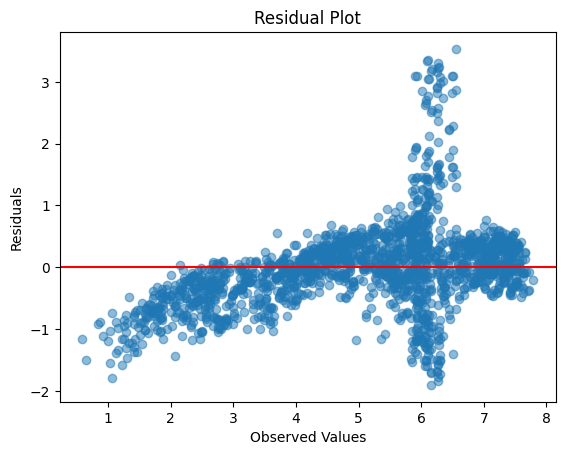

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

residuals = y_test - y_pred
plt.scatter(y_test, residuals, alpha=0.5)
# plotting y = 0
plt.axhline(y=0, color='r',)
plt.xlabel('Observed Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

The resulting residual plot shows that the derived Linear Regression Model is quite weak. In an ideal residual plot, all the residual values must be distributed centrally around the y-axis (y = 0) with constant variance and must not display any type of patten/trend.

Both of these requirements are not met in the graphed plot. There appears to be some distortion of the data at x = 6 which violates the constant variance requirement. Furthermore, for lower values (x < 4) the data points are no longer centrally distributed. It appears that there is a pattern in the data values as they seem to follow a non-linear curve across the range of values.

All of these lead us to beleieve that this is a poor linear regression.



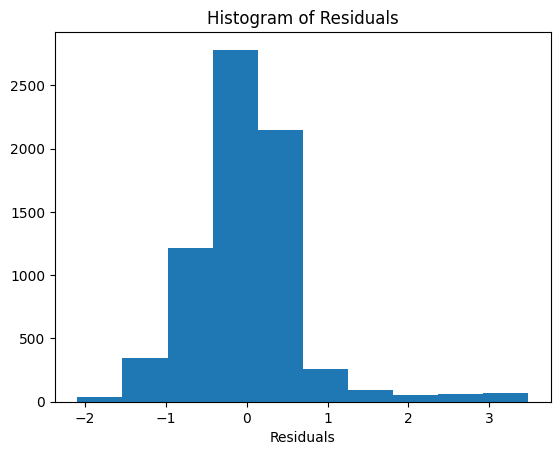

In [ ]:
plt.hist(y_train - model.predict(X_train))
plt.xlabel('Residuals')
plt.title('Histogram of Residuals')
plt.show()

The histograms of residuals tells the same story. In an ideal linear regression model, all of the calculated residuals should also closely mirror a normal distribution (bell-curve).

In the graph above however, this doesn't seem to be the case for residuals > 1. This is again likely due to the nature of the data not being well suited for a Linear Regression Task.

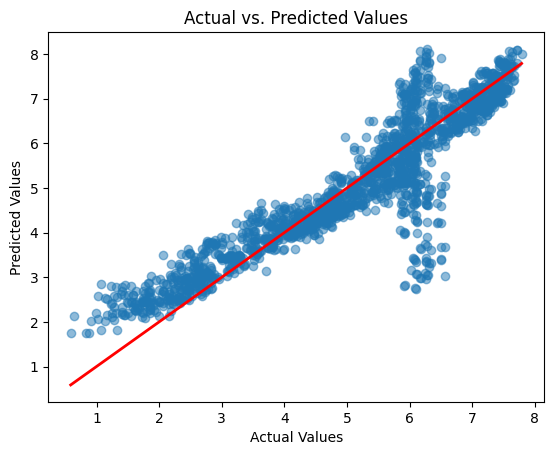

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)
# prints the line y = x
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

Finally, we can also directly compare the results of our model to what the theoretical values should be. By plotting theoretical vs. predicted, we can see just how off the model's predicted values can be for the same input.

For a model to be a good fit, the predicted and actual values should exhibit good correspondence which would be seen if the data points followed the line y = x (In red). However, this is not the case with Linear Regression.

## ML Models: Decision Tree Regressor

The previous ML model indicated that our data might be more complex than orignally thought. To better address this issue, a more complex model might be needed. Decision Trees are one such model.

Decision Trees offer us the opportunity to fit a non-linear model, which increases the complexity greatly. Due to them 'splitting' based on indiviudal features, they can explore and capture far more complex behaviour in the dataset. At the same time, they are also pretty resistant to outliers since splits are determined based on how well they partition the data by minimzing error metrics like entropy.

However, this type of Model is extremely prone to overfitting data since it can just 'learn' the best splits of the training data or split indefinitely so that it captures every data record. For this reason, we begin by limiting the max_depth of the Decision Tree to just 10, which is much lower than the number of features in X.

In [ ]:
# imports
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
# Init model + train
model = DecisionTreeRegressor(random_state=random_state, max_depth=10)
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

After training the model, we now need to evaluate the results. This can be done by predicting values using the model and comparing them to the true values. Metrics like MAE, MSE and R^2 are useful

In [ ]:
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R²: {r2}")

MAE: 0.20990845554995466
MSE: 0.16233456523910997
R²: 0.9446216478756939


The Decision Tree Regression model achieves a much better fit with an R^2 of 0.945 and Mean R^2 of 0.927. Furthermore, the MAE and MSE values have also dropped to 0.210 and 0.162 respectively. This means there is lesser deviation between the model and the training values than linear regression.

Since the mean R^2 that comes from cross validation is also sufficiently high, it is safe to also conclude that the model generalizes pretty well over the dataset.

Like before, we now visualize the results of the model and compare them to the actual values. To do this, the following plots are produced:

* Residual Plot
* Actual Vs. Predicted

Additionally, Decision Trees allow use to view which features contribute the most. So, a Feature importance graph will also be created.

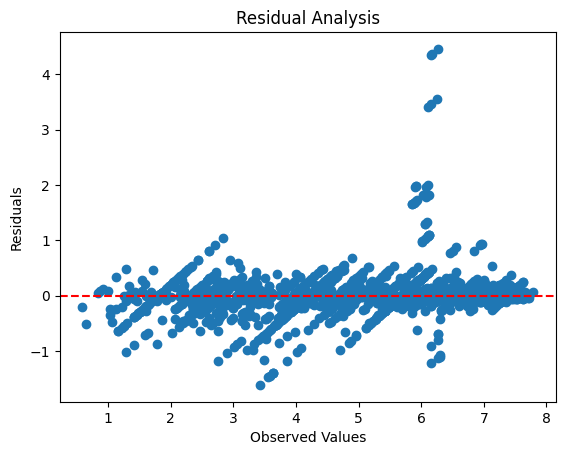

In [ ]:
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Observed Values')
plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.show()

The residual plot performs substantially better than that of the Linear Regression. It appears that the values are distributed with almost constant variance around y = 0 (red line) and that there is no inherent trend in this plot. There still are a few outliers, but overall the residual plots show encouraging signs.

The main concern in this residual plot is the 'stepped' nature of the data. This however is to be expected from a Decision Tree simply due to the way it is trained. The model makes discrete 'splits' at each feature that might be causing the stepped behavior.

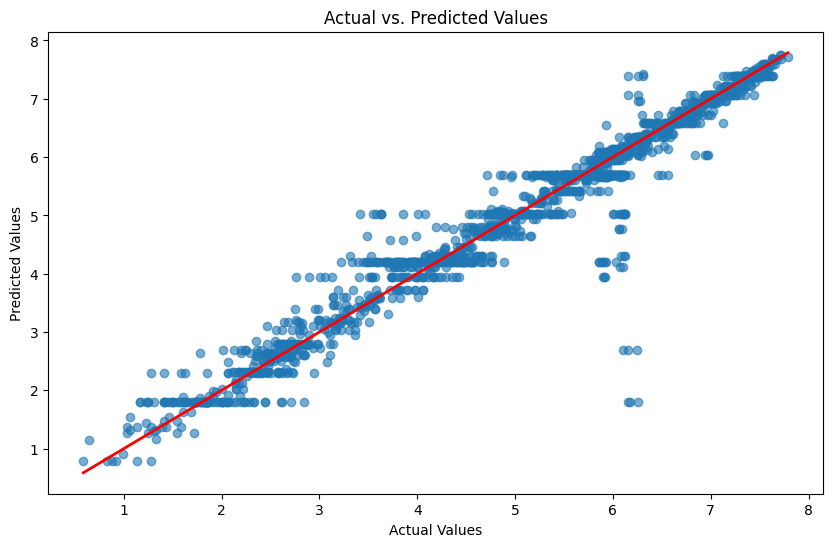

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

A similar story is present in the predicted vs. actual plots. Of course, there is a huge improvement over Linear Regression as the values mostly follow the red line (y = x), which indicates that the model predicts in line with the actual values. But again, the data itself looks 'stepped', which as explained earlier, might be the results of the model itself.

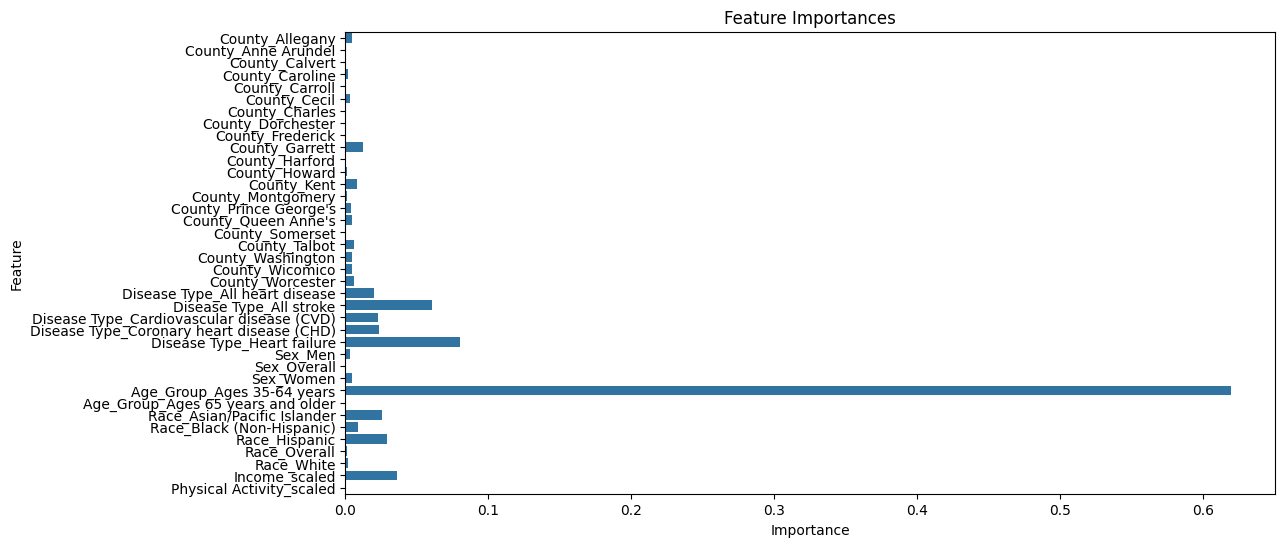

In [ ]:
# Get contribution of each feature
feature_importances = model.feature_importances_

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances, y=X_train.columns)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

Now looking at Feature Importances, we can see a few features have a high impact on the target variable. Firstly, we can see that Age plays a big role in this Model, and as explained in EDA, this is expected as younger people are less likely to have high mortality.

Next, it seems that the type of heart disease also has a say in the mortality rates. Diseases like Stroke and Heart Failure have a higher contribution than CVD and CHD. This interaction might be a result of certain disease types being more fatal than others.

Race and Income also play a role according to the graph as well as certain coutnies like Garrett County and Kent County.

## ML Models: Random Forest Regressor

A key issue faced in Decision Tree was the stepped nature of the data. This can be solved by using Random Forests, which uses ensemble methods to run multiple simultaneous Decision Trees and 'combine' the results of the best tree to build a better model. Again, we force max_depth to 10 for each tree to ensure that the model doesn't overfit.

In [374]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R^2: {r2:.2f}")

scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
print("Cross Validation Mean R^2:", scores.mean())



MAE: 0.14
MSE: 0.14
R^2: 0.95
Cross Validation Mean R^2: 0.9488368648350983


The MSE, MAE R^2 and Mean R^2 values all seem to perform better than a single Decision Tree. So lets vizualize the results.

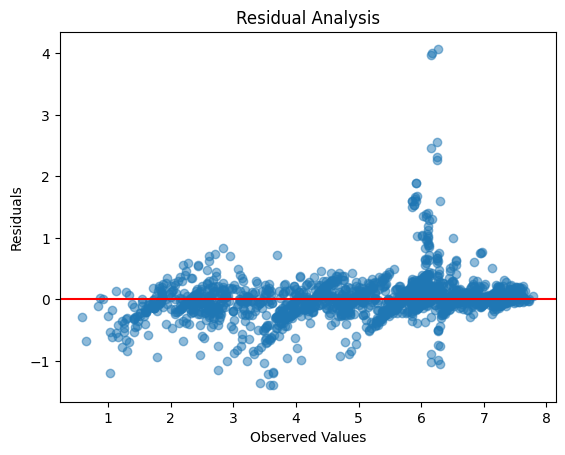

In [375]:
residuals = y_test - y_pred
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r')
plt.xlabel('Observed Values')
plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.show()

There doesn't seem to be a great improvement in the residual patterns with the exception of the 'stepped' pattern being gone. This is exactly what the Random Forests Model set out to do, which is good.  

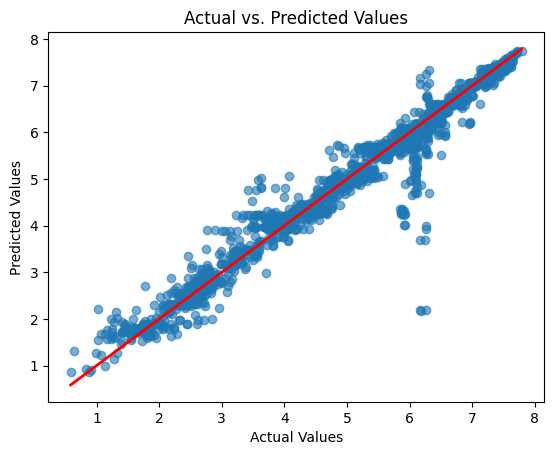

In [376]:
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

Again, there are incremental improvements in terms of the fit of the plots but the main takeaway is that the Random Forests Model was able to eliminate the 'stepped' pattern present in the Decision Tree. Just like DT, RF is also a good model.

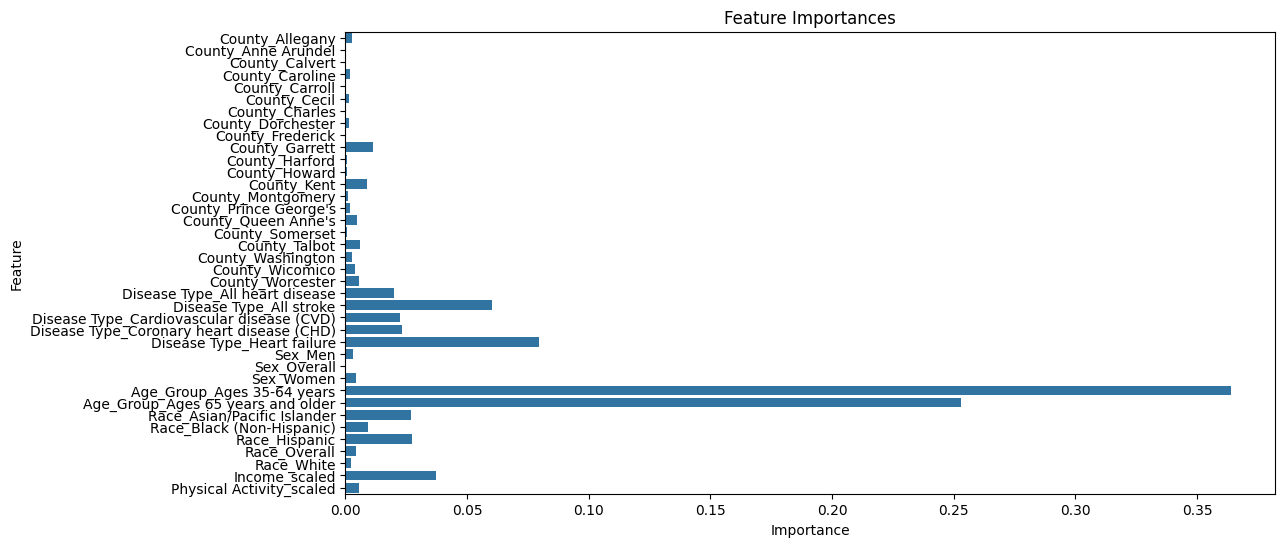

In [377]:
feature_importances = rf_model.feature_importances_

# Create a bar plot of feature importances
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances, y=X_train.columns)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

It appears that the Random Forests has been able to learn from more features than Decision Tree though. New feature importances are being given to older ages and Physical Acitivty, while the existing feature importances from DT are being strenghtened.

## Improving Random Forest with Grid Search
Grid Search is a technique through which hyperparameters can be experimented with to find the best value. In particular, we are interested to see if changing the max_depth of a RF Model can positively impact the model. So, we try to experiment with various depths and find the best result.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {'max_depth': [5, 10, 15, 20, 25, 30, 40, 50]}
rf = RandomForestRegressor(n_estimators=100, random_state=42)
grid_search_rf = GridSearchCV(rf, param_grid_rf, scoring='neg_mean_squared_error', cv=5, n_jobs = -1)
grid_search_rf.fit(X_train, y_train)
print("Best max_depth for Random Forest:", grid_search_rf.best_params_)

Best max_depth for Random Forest: {'max_depth': 30}


Now we train the new RF with the best hyperparams.

Mean Squared Error (MSE): 0.06
Root Mean Squared Error (RMSE): 0.25
R² Score: 0.98


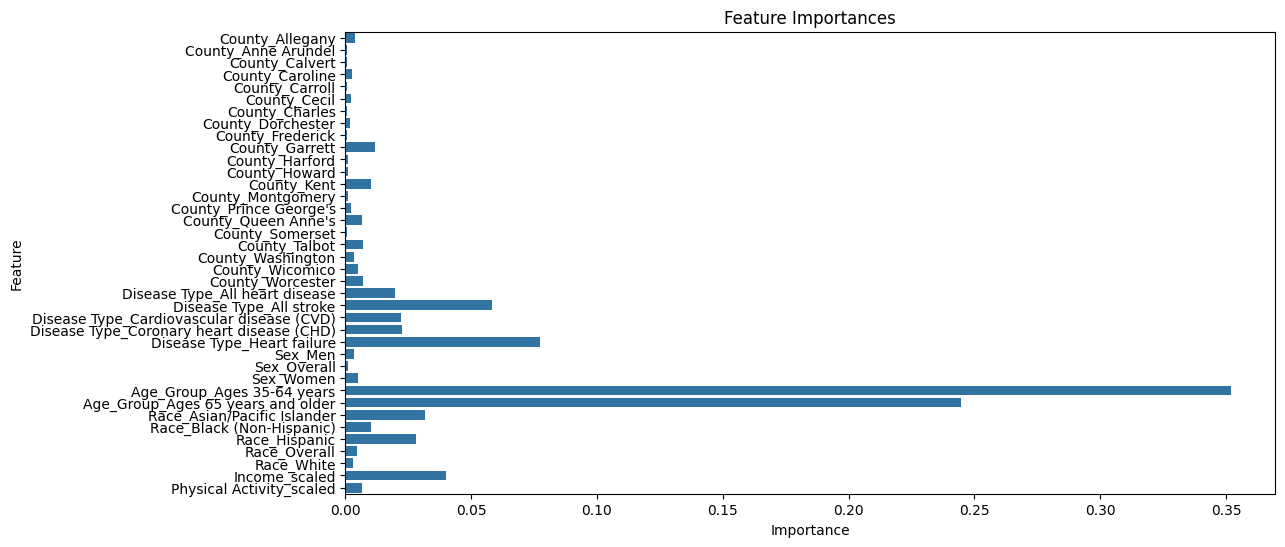

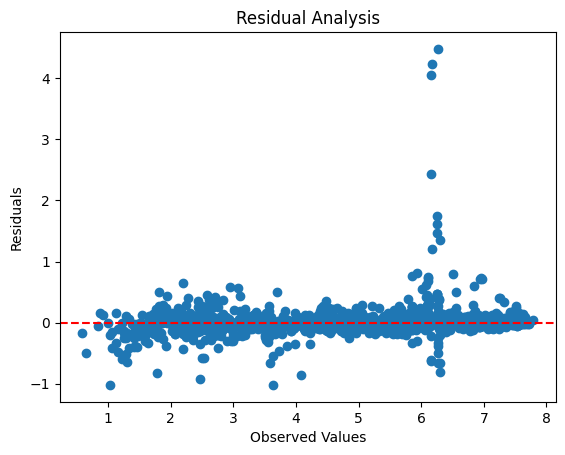

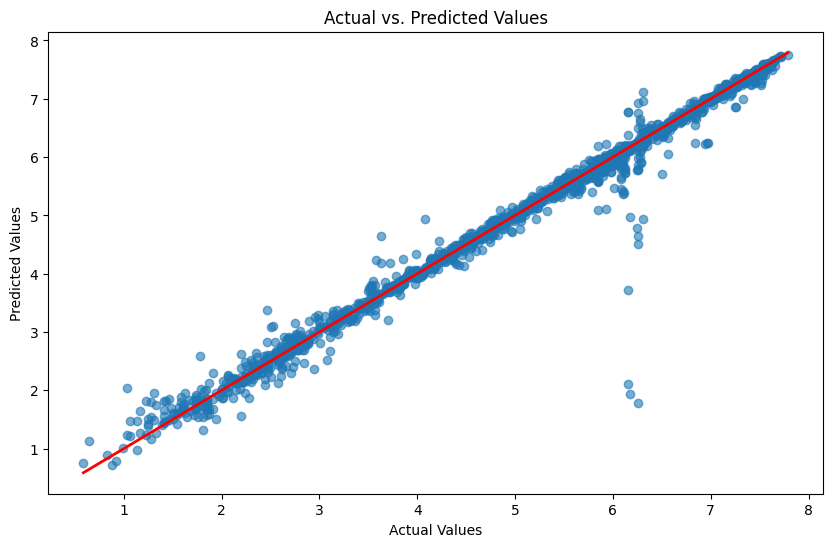

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=grid_search_rf.best_params_['max_depth'],
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

feature_importances = rf.feature_importances_
feature_importance_df_heat = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importances, y=X_train.columns)
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Observed Values')
plt.ylabel('Residuals')
plt.title('Residual Analysis')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

All the metrics (MSE, R^2) indicate that a RF with max_depth = 30 is the best fitting model so far.

The plots indicate that the performance of the model is marginally better, with both residual and predicted vs. actual plots showing a non-stepped prediction pattern.

Further, it seems that the importances have been strengthened even further, meaning the contributions of existing features is confirmed yet again.

# Insights and Conclusions

In [ ]:
import shap
import pandas as pd

In [ ]:
feature_importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({ 'Feature': X_train.columns, 'Importance': feature_importances }).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance_df)



Feature Importances:
                                      Feature  Importance
29                 Age_Group_Ages 35-64 years    0.352041
30          Age_Group_Ages 65 years and older    0.244830
25                 Disease Type_Heart failure    0.077210
22                    Disease Type_All stroke    0.058420
36                              Income_scaled    0.039931
31                Race_Asian/Pacific Islander    0.031622
33                              Race_Hispanic    0.028190
24  Disease Type_Coronary heart disease (CHD)    0.022373
23  Disease Type_Cardiovascular disease (CVD)    0.021986
21             Disease Type_All heart disease    0.019752
9                              County_Garrett    0.011778
12                                County_Kent    0.010332
32                  Race_Black (Non-Hispanic)    0.010093
17                              County_Talbot    0.007079
20                           County_Worcester    0.006817
37                   Physical Activity_scaled    0

<Axes: >

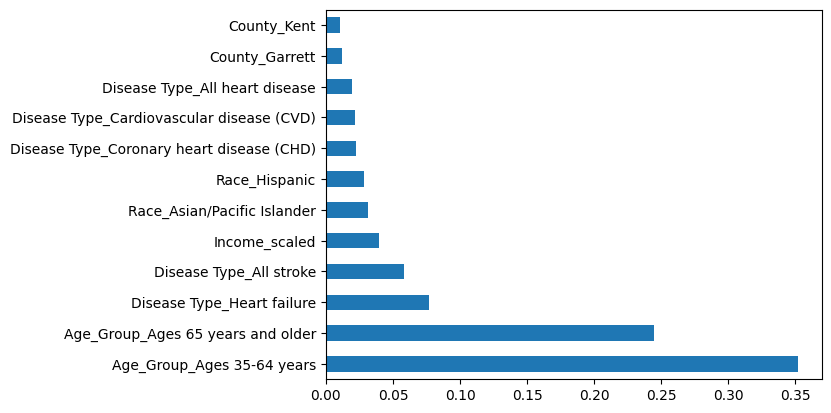

In [ ]:
feat_importances = pd.Series(rf.feature_importances_, index = X_train.columns)
feat_importances.nlargest(12).plot(kind = 'barh')

For models like RandomForestRegressor the feature importance is tracked while the type of correlation is not. We wanted to find the type of correlation different features have so we utilzed shap.TreeExplainer to visualize this.

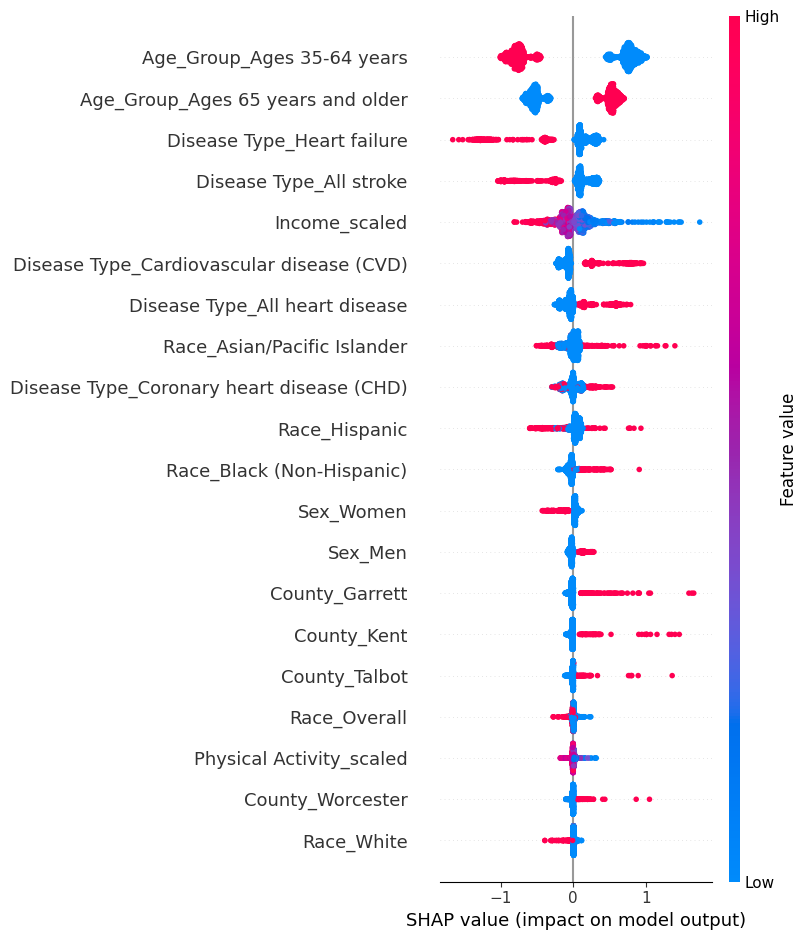

In [ ]:
ex = shap.TreeExplainer(rf)
shap_values = ex.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
#positive correlations are blue to red left to right
#negative correlations are red to blue
#the range shows the amount of impact

This graph shows the correlation between the feature on the left and mortality rate through the color.
Continuous data will be a range of values that either have a positive correlation shown through a shift of blue to red from the left to right, a negative correlation shown through a shift from red to blue, or no correlation. This data will have purple in it to show the shift.
Categorical data will be graphed as blue data points centered at 0 or no impact since not being in the category isn’t what we’re focusing on. The red points or the points of what the impact of being in the category is. So red points to the right of 0 mean a positive correlation and blue points mean a negative correlation.
The distance from the center line corresponds to the amount of impact being in the category has.



From the graph we see that being younger than 65 has a negative correlation while being older than 65 has a positive correlation. We can also see that the age group younger than 65’s data points are further from the center line compared to the data points for being older than 65 which means that being younger than 65 has a stronger correlation than being older than 65 does. While we aren’t completely sure why the age data has this shape differing from the other categorical variables we suspect it is due to the extremity of the values.

Cardiovascular diseases and heart diseases are positively correlated with mortality rates. Income, on the other hand, shows a strong negative correlation with mortality, with physical activity having a much weaker negative correlation.

For gender, women are negatively correlated with mortality rates, whereas men are positively correlated, with the effect for women being stronger than that for men. When analyzing race, Black individuals have a stronger positive correlation with mortality rates compared to the weaker negative correlation observed for White individuals.

Among Maryland’s counties, the top four most influential counties show a positive correlation with mortality rates, with Garrett County exhibiting the strongest positive correlation. Other counties in the state do not show significant correlations.


#BONUS ML Model: Neural Network

We also decided to see if attacking this model using NN is a feasible solution. To do this, we try to implement a Multi-layer feed forward network that uses the ADAM optmizer

In [379]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [381]:
batch_size = 32

train_features = torch.tensor(X_train.values, dtype=torch.float32)
train_targets = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
test_features = torch.tensor(X_test.values, dtype=torch.float32)
test_targets = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(train_features, train_targets)
test_dataset = TensorDataset(test_features, test_targets)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

feat_dim = X_train.shape[1]

The model is a 3 layer model with 1 hidden layer that contains 128 inputs.

In [ ]:
class MLPModel(nn.Module):
    def __init__(self, feat_dim):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(feat_dim, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MLPModel(feat_dim)

Using a similar training method as HW5:

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

epochs = 100
losses = []
for epoch in range(epochs):
    running_loss = 0.0
    for batch_idx, (data, targets) in enumerate(train_loader):
        pred = model(data)
        loss = criterion(pred, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    losses.append(loss.item())
    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item()}')

print('Finished Training')

Epoch 1/100, Loss: 0.6180262565612793
Epoch 2/100, Loss: 0.3505920171737671
Epoch 3/100, Loss: 0.7918599843978882
Epoch 4/100, Loss: 0.1303536742925644
Epoch 5/100, Loss: 0.05712771415710449
Epoch 6/100, Loss: 0.03171912580728531
Epoch 7/100, Loss: 0.12510550022125244
Epoch 8/100, Loss: 0.08974096924066544
Epoch 9/100, Loss: 0.0300369244068861
Epoch 10/100, Loss: 0.04509372636675835
Epoch 11/100, Loss: 0.0794365257024765
Epoch 12/100, Loss: 0.029062602669000626
Epoch 13/100, Loss: 0.03448960930109024
Epoch 14/100, Loss: 0.013601629994809628
Epoch 15/100, Loss: 0.025212010368704796
Epoch 16/100, Loss: 0.007741420064121485
Epoch 17/100, Loss: 0.01651059091091156
Epoch 18/100, Loss: 0.010084506124258041
Epoch 19/100, Loss: 0.010977290570735931
Epoch 20/100, Loss: 0.010945213958621025
Epoch 21/100, Loss: 0.007066465448588133
Epoch 22/100, Loss: 0.016459718346595764
Epoch 23/100, Loss: 0.0425255186855793
Epoch 24/100, Loss: 0.04082633927464485
Epoch 25/100, Loss: 0.014609578996896744
Epoch 

We now try to plot loss as a function over time. This code is used from HW5

Train Loss: 0.00469449505934753
Test Loss: 0.0072928791133953


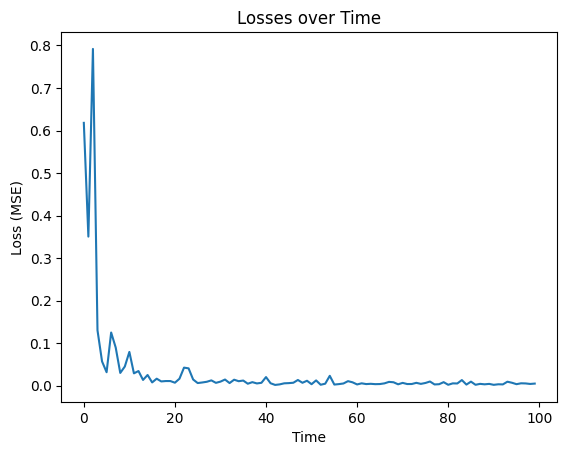

In [ ]:
test_loss = 0.0
for batch_idx, (data, targets) in enumerate(test_loader):
    loss = criterion(model(data), targets)
    test_loss += loss.item()
test_loss = test_loss / len(test_loader)

train_loss = 0.0

for batch_idx, (data, targets) in enumerate(train_loader):
    loss = criterion(model(data), targets)
    train_loss += loss.item()
train_loss = train_loss / len(train_loader)

print("Train Loss:", train_loss)
print("Test Loss:", test_loss)

plt.plot(losses)
plt.title("Losses over Time")
plt.xlabel("Time")
plt.ylabel("Loss (MSE)")
plt.show()

The NN trains well as loss decreases almost immediatly to a very small value. However, we must excersize caution as the NN might be overfitting greatly. Unfortunately, we were not able to find effective ways of interpreting the NN's learnings and comment on them